# NIJ Georgia Recidivism Forecasting Challenge データによる実証分析

論文 *Rethinking Recidivism Risk Assessment Tool: From Prediction to Policy Learning* の主張（予測 $\mathbb{E}[r\mid x]$ に基づく割当ては意思決定として不十分で、処遇 $a$ を組み込んだ DM / DR-OPL が適切）が、実データでも **方向として** 観察されるかを確認する。

- 計画: `plans/nij_georgia_analysis.md`（承認済み）
- 位置づけ: feasibility のデモ。反実仮想が観測できないので、方策価値はすべて **識別の仮定（無交絡・positivity）の下での推定値**。因果効果として解釈しない。
- 実行環境: Colab 前提（ローカルでも実行可）。

| 記号 | 本分析での定義 |
|---|---|
| $r$ | `Recidivism_Within_3years`（監督開始から 3 年以内の新たな犯罪での逮捕） |
| $a$ | `Supervision_Level_First` ∈ {High, Specialized} → 1、Standard → 0 |
| $x$ | 監督開始前に確定している変数のみ（属性・前歴・服役情報・初回リスクスコア・仮釈放条件） |

In [1]:
# @title 0. パスとデータの準備（Colab / ローカル共通）
import os, sys, hashlib, subprocess, urllib.request
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    ROOT = Path('/content/commentary_mjca')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', 'https://github.com/MasaAsami/commentary_mjca.git', str(ROOT)], check=True)
else:
    ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

RAW, PROC, OUT = ROOT / 'data/raw', ROOT / 'data/processed', ROOT / 'outputs/nij'
TAB, FIG = OUT / 'tables', OUT / 'figs'
for p in [RAW, PROC, TAB, FIG]:
    p.mkdir(parents=True, exist_ok=True)

DATA_URL = 'https://nij.ojp.gov/sites/nij/files/media/document/nij-challenge2021_full_dataset.csv'
DATA_SHA256 = '2df247209bea3ad2d861ef1624461ef73b5b792f01593da0b6f18e3de1b72f5c'
RAW_CSV = RAW / 'nij-challenge2021_full_dataset.csv'

# raw がなければ公式 URL から取得（raw は上書きしない）
if not RAW_CSV.exists():
    urllib.request.urlretrieve(DATA_URL, RAW_CSV)
sha = hashlib.sha256(RAW_CSV.read_bytes()).hexdigest()
assert sha == DATA_SHA256, f'SHA-256 mismatch: {sha}'
print('ROOT =', ROOT, '| raw data verified')

ROOT = /Users/hdymacuser/Develop/commentary_mjca | raw data verified


In [2]:
# @title パッケージの読み込み
import random
import numpy as np
import pandas as pd
import lightgbm as lgb
import statsmodels.api as sm
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.linear_model import LogisticRegression

sns.set_style("ticks")
sns.set_context("paper")
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

# 図の色（dataviz 参照パレットの先頭 3 色 + 中立グレー）
C_BLUE, C_ORANGE, C_AQUA, C_GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#7a7974'

# macOS では LightGBM と PyTorch の OpenMP が衝突してハングするため、PyTorch を 1 スレッドにする（小さな NN なので影響は軽微）
torch.set_num_threads(1)

SEED = 42
MAIN_SEEDS = tuple(range(10))  # DR-OPL（NN）の seed。全仕様で 10 本の平均方策を使う
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
set_seed(SEED)

## 1. データの読み込みと変数の整備

- 列名 `_v1`–`_v4` は codebook の位置 18, 26–28 に対応（`data/README.md` 参照）。派生データ上でのみ名前を変更する。
- **監督開始後に測定される変数（Supervision Activities: `Violations_*`, `DrugTests_*`, `Program_*`, 就労など）は事後変数なので使わない。**
- `Gang_Affiliated` は女性全員で欠損（構造的欠損）。「Yes なら 1、それ以外 0」とし、女性であることは `male` で表す。

In [3]:
# @title 1-1. 読み込みと符号化
raw = pd.read_csv(RAW_CSV)
print('raw shape:', raw.shape)

df = raw.rename(columns={
    '_v1': 'Prior_Arrest_Episodes_PPViolationCharges',
    '_v2': 'Prior_Conviction_Episodes_PPViolationCharges',
    '_v3': 'Prior_Conviction_Episodes_DVCharges',
    '_v4': 'Prior_Conviction_Episodes_GunCharges',
}).copy()

POST_TREATMENT = [c for c in df.columns if c.startswith(('Violations_', 'DrugTests_', 'Program_'))] + [
    'Delinquency_Reports', 'Residence_Changes', 'Avg_Days_per_DrugTest',
    'Percent_Days_Employed', 'Jobs_Per_Year', 'Employment_Exempt']
OUTCOMES = ['Recidivism_Within_3years', 'Recidivism_Arrest_Year1', 'Recidivism_Arrest_Year2', 'Recidivism_Arrest_Year3']

def lead_int(s):
    # '10 or more' -> 10, '3 or more' -> 3, '2' -> 2
    return s.astype(str).str.extract(r'(\d+)')[0].astype(float)

def yes_no(s):
    return s.map({'Yes': 1, 'No': 0}).astype(float)

AGE_MAP = {'18-22': 1, '23-27': 2, '28-32': 3, '33-37': 4, '38-42': 5, '43-47': 6, '48 or older': 7}
PRISON_YEARS_MAP = {'Less than 1 year': 0, '1-2 years': 1, 'Greater than 2 to 3 years': 2, 'More than 3 years': 3}
EDU_MAP = {'Less than HS diploma': 1, 'High School Diploma': 2, 'At least some college': 3}

X = pd.DataFrame(index=df.index)
X['male'] = (df['Gender'] == 'M').astype(float)
X['black'] = (df['Race'] == 'BLACK').astype(float)
X['age_group'] = df['Age_at_Release'].map(AGE_MAP).astype(float)
X['gang_affiliated'] = (df['Gang_Affiliated'] == 'Yes').astype(float)
X['risk_score_missing'] = df['Supervision_Risk_Score_First'].isna().astype(float)
X['risk_score'] = df['Supervision_Risk_Score_First']  # 欠損は後で train の中央値で補完
X['education'] = df['Education_Level'].map(EDU_MAP).astype(float)
X['dependents'] = lead_int(df['Dependents'])
X['prison_years'] = df['Prison_Years'].map(PRISON_YEARS_MAP).astype(float)

prior_cols = [c for c in df.columns if c.startswith(('Prior_Arrest_Episodes_', 'Prior_Conviction_Episodes_', 'Prior_Revocations_'))]
for c in prior_cols:
    X[c] = yes_no(df[c]) if set(df[c].dropna().unique()) <= {'Yes', 'No'} else lead_int(df[c])
for c in ['Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other']:
    X[c] = yes_no(df[c])

# 服役罪種（基準: Property、欠損はカテゴリとして扱う）
offense = df['Prison_Offense'].fillna('Missing')
for lv in ['Violent/Sex', 'Violent/Non-Sex', 'Drug', 'Other', 'Missing']:
    X['offense_' + lv.replace('/', '_').replace('-', '_')] = (offense == lv).astype(float)
# 居住 PUMA（基準: 1）
for p in sorted(df['Residence_PUMA'].unique())[1:]:
    X[f'puma_{p}'] = (df['Residence_PUMA'] == p).astype(float)

# アウトカム・処遇・分割
Y = pd.DataFrame({c: yes_no(df[c]) for c in OUTCOMES})
level = df['Supervision_Level_First']
TRAIN = df['Training_Sample'] == 1

assert not X.drop(columns='risk_score').isna().any().any()
assert not set(X.columns) & set(POST_TREATMENT)
print('baseline covariates:', X.shape[1])

raw shape: (25835, 54)


baseline covariates: 59


In [4]:
# @title 1-2. 欠損の確認
miss = raw.isna().mean().rename('missing_rate').to_frame()
miss['n_missing'] = raw.isna().sum()
miss['timing'] = np.where(miss.index.isin(POST_TREATMENT), 'post-treatment (excluded)', 'baseline / treatment / outcome')
miss = miss[miss['n_missing'] > 0].sort_values('missing_rate', ascending=False)
miss.to_csv(TAB / 'missingness.csv')
display(miss)

# 処遇が欠損している行の特徴（除外による選択の方向を記録）
print('処遇欠損の行数:', level.isna().sum(), f'({level.isna().mean():.1%})')
print('  3年再逮捕率: 欠損', Y.loc[level.isna(), 'Recidivism_Within_3years'].mean().round(3),
      '/ 非欠損', Y.loc[level.notna(), 'Recidivism_Within_3years'].mean().round(3))
print('  うちリスクスコアも欠損:', X.loc[level.isna(), 'risk_score_missing'].mean().round(3))

,missing_rate,n_missing,timing
Avg_Days_per_DrugTest,0.236230,6103,post-treatment (excluded)
DrugTests_THC_Positive,0.200194,5172,post-treatment (excluded)
DrugTests_Cocaine_Positive,0.200194,5172,post-treatment (excluded)
DrugTests_Meth_Positive,0.200194,5172,post-treatment (excluded)
DrugTests_Other_Positive,0.200194,5172,post-treatment (excluded)
Prison_Offense,0.126843,3277,baseline / treatment / outcome
Gang_Affiliated,0.122586,3167,baseline / treatment / outcome
Supervision_Level_First,0.066576,1720,baseline / treatment / outcome
Jobs_Per_Year,0.031275,808,post-treatment (excluded)
Supervision_Risk_Score_First,0.018386,475,baseline / treatment / outcome


処遇欠損の行数: 1720 (6.7%)
  3年再逮捕率: 欠損 0.63 / 非欠損 0.573
  うちリスクスコアも欠損: 0.183


In [5]:
# @title 1-3. 分析サンプル（処遇が観測されている人）
keep = level.notna()
data = X[keep].copy()
data['level'] = level[keep]
data['A'] = level[keep].isin(['High', 'Specialized']).astype(int)
for c in OUTCOMES:
    data[c] = Y.loc[keep, c].astype(int)
data['train'] = TRAIN[keep].astype(int)
data['ID'] = df.loc[keep, 'ID']

# リスクスコアの欠損は train の中央値で補完（欠損指示変数は保持）
RISK_MEDIAN = data.loc[data.train == 1, 'risk_score'].median()
data['risk_score'] = data['risk_score'].fillna(RISK_MEDIAN)

data.to_csv(PROC / 'nij_analysis_sample.csv', index=False)
print('analysis sample:', data.shape, '| train', data.train.sum(), '/ test', (1 - data.train).sum())

X_ALL = list(X.columns)  # 全ベースライン共変量（記述統計用）
RISK_VARS = ['risk_score', 'risk_score_missing']
# 方策の学習・評価のすべてで使う共通の特徴量（Race と Georgia のリスクスコアを除く 56 変数。apples-to-apples）
X_POL_MAIN = [c for c in X_ALL if c != 'black' and c not in RISK_VARS]

analysis sample: (24115, 67) | train 16816 / test 7299


## 2. 処遇群サイズ・記述統計・共変量バランス

In [6]:
# @title 2-1. 処遇群サイズと再逮捕率
grp = data.groupby(['train', 'level']).agg(
    n=('A', 'size'),
    recid_3y=('Recidivism_Within_3years', 'mean'),
    recid_y1=('Recidivism_Arrest_Year1', 'mean')).round(3)
grp.to_csv(TAB / 'group_sizes.csv')
display(grp)
print('処遇割合 P(A=1):', data.groupby('train')['A'].mean().round(3).to_dict())

n  recid_3y  recid_y1
train level                                
0     High         2106     0.629     0.332
      Specialized  2181     0.593     0.315
      Standard     3012     0.512     0.260
1     High         4903     0.641     0.340
      Specialized  4942     0.587     0.309
      Standard     6971     0.518     0.257

処遇割合 P(A=1): {0: 0.587, 1: 0.585}


In [7]:
# @title 2-2. 共変量バランス（標準化平均差）
def smd(x, a, w=None):
    w = np.ones_like(x, dtype=float) if w is None else w
    m1 = np.average(x[a == 1], weights=w[a == 1]); m0 = np.average(x[a == 0], weights=w[a == 0])
    v1 = np.var(x[a == 1]); v0 = np.var(x[a == 0])  # 分母は未調整の分散（慣例）
    return (m1 - m0) / np.sqrt((v1 + v0) / 2 + 1e-12)

main_vars = [c for c in X_ALL if not c.startswith('puma_')]
bal = pd.DataFrame({
    'mean_A1': data.loc[data.A == 1, main_vars].mean(),
    'mean_A0': data.loc[data.A == 0, main_vars].mean(),
    'SMD_raw': [smd(data[c].values, data.A.values) for c in main_vars]}).round(3)

## 3. Overlap / common support の診断（モデリング前のゲート）

事前指定の判定ルール（計画 §3.3）: cross-fitted $\hat\pi_0 \notin [0.05, 0.95]$ の割合が 20% を超える場合や、スコア帯の一部で片方の群がほぼゼロの場合は、OPL の推定を「識別困難」として止め、相談する。

In [8]:
# @title 3-1. モデル定義（既存 notebooks/mjca_simdata.ipynb と同じ LightGBM 設定）
LGB_PARAMS = {'objective': 'binary', 'metric': 'binary_logloss', 'verbosity': -1, 'seed': SEED}

def fit_lgb(Xm, y, seed=SEED):
    return lgb.train({**LGB_PARAMS, 'seed': seed}, lgb.Dataset(Xm, y), num_boost_round=100)

def fit_ps(Xm, a, ps_model='lgb', seed=SEED):
    # 傾向スコアモデル。'lgb'（既定）または 'logit'（標準化 + ロジスティック回帰。確率の較正が良い）
    if ps_model == 'lgb':
        m = fit_lgb(Xm, a, seed)
        return lambda Z: m.predict(Z)
    mu, sd = Xm.mean(), Xm.std().replace(0, 1)
    m = LogisticRegression(max_iter=5000, C=1.0).fit((Xm - mu) / sd, a)
    return lambda Z: m.predict_proba((Z - mu) / sd)[:, 1]

def crossfit_nuisance(d, x_cols, outcome, treat='A', k=5, seed=SEED, ps_model='lgb'):
    # 5-fold cross-fitting による ê(x)=P(A=1|x), q̂(x,0), q̂(x,1)
    n = len(d)
    e, q0, q1 = np.zeros(n), np.zeros(n), np.zeros(n)
    strata = d[treat].values * 2 + d[outcome].values
    for tr, te in StratifiedKFold(k, shuffle=True, random_state=seed).split(np.zeros(n), strata):
        dtr, dte = d.iloc[tr], d.iloc[te]
        m_e = fit_ps(dtr[x_cols], dtr[treat], ps_model, seed)
        m_q = fit_lgb(dtr[x_cols].assign(A=dtr[treat].values), dtr[outcome], seed)
        e[te] = m_e(dte[x_cols])
        q0[te] = m_q.predict(dte[x_cols].assign(A=0))
        q1[te] = m_q.predict(dte[x_cols].assign(A=1))
    return e, q0, q1

def ess(w):
    return w.sum() ** 2 / (w ** 2).sum()

In [9]:
# @title 3-2. overlap 診断（全サンプル、5-fold cross-fitting）
e_all, _, _ = crossfit_nuisance(data, X_POL_MAIN, 'Recidivism_Within_3years')
data['e_cf'] = e_all
A = data.A.values
w_ipw = np.where(A == 1, 1 / e_all, 1 / (1 - e_all))
out_share = np.mean((e_all < 0.05) | (e_all > 0.95))

overlap = pd.Series({
    'AUC of pi0_hat (cross-fitted)': roc_auc_score(A, e_all),
    'share e<0.05 or e>0.95': out_share,
    'share e<0.01 or e>0.99': np.mean((e_all < 0.01) | (e_all > 0.99)),
    'min e (A=1)': e_all[A == 1].min(), 'max e (A=0)': e_all[A == 0].max(),
    'ESS / n (treated)': ess(w_ipw[A == 1]) / (A == 1).sum(),
    'ESS / n (control)': ess(w_ipw[A == 0]) / (A == 0).sum(),
}).round(3)
overlap.to_csv(TAB / 'overlap_diagnostics.csv')
display(overlap)

# スコア帯×処遇
score_tab = pd.crosstab(X.loc[keep, 'risk_score'].fillna(-1).astype(int).replace(-1, 'NA'), data.level, margins=True)
score_tab.to_csv(TAB / 'risk_score_by_level.csv')
min_share_by_score = pd.crosstab(data.risk_score.round(), data.A, normalize='index').min(axis=1)

OVERLAP_OK = (out_share <= 0.20) and (min_share_by_score.min() >= 0.05)
print('score 帯ごとの少数群の割合（最小）:', min_share_by_score.min().round(3))
print('OVERLAP GATE:', 'PASS' if OVERLAP_OK else 'FAIL -> 相談（計画 §3.3）')

# IPW 後のバランス
bal['SMD_ipw'] = [smd(data[c].values, A, w_ipw) for c in main_vars]
bal = bal.round(3)
bal.to_csv(TAB / 'covariate_balance.csv')
display(bal.sort_values('SMD_raw', key=abs, ascending=False).head(15))

AUC of pi0_hat (cross-fitted)    0.768
share e<0.05 or e>0.95           0.040
share e<0.01 or e>0.99           0.011
min e (A=1)                      0.039
max e (A=0)                      0.994
ESS / n (treated)                0.706
ESS / n (control)                0.266
dtype: float64

score 帯ごとの少数群の割合（最小）: 0.128
OVERLAP GATE: PASS


,mean_A1,mean_A0,SMD_raw,SMD_ipw
risk_score,7.214,4.772,1.208,0.821
age_group,3.396,4.486,-0.609,-0.039
prison_years,1.474,1.096,0.341,-0.005
offense_Violent_Sex,0.057,0.001,0.339,-0.080
Condition_Other,0.390,0.251,0.301,0.005
gang_affiliated,0.192,0.106,0.243,-0.005
offense_Drug,0.159,0.251,-0.229,-0.009
offense_Missing,0.100,0.166,-0.195,-0.009
Condition_Cog_Ed,0.486,0.396,0.183,-0.003
Prior_Arrest_Episodes_Misd,3.100,3.495,-0.173,-0.010


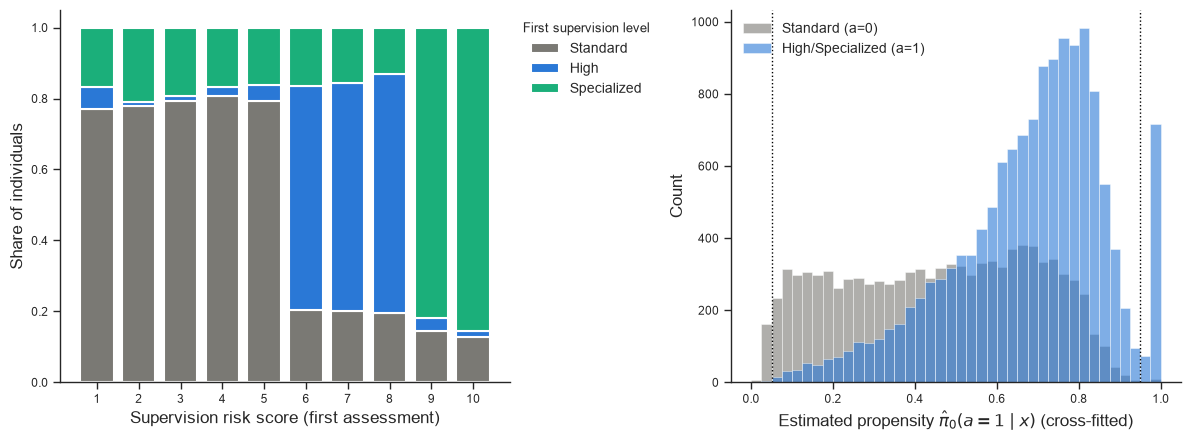

In [10]:
# @title 3-3. 図 1: overlap（リスクスコア×監督レベル、傾向スコア分布）
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

share = pd.crosstab(data.loc[data.risk_score_missing == 0, 'risk_score'].astype(int),
                    data.loc[data.risk_score_missing == 0, 'level'], normalize='index')[['Standard', 'High', 'Specialized']]
bottom = np.zeros(len(share))
for col, c in zip(share.columns, [C_GRAY, C_BLUE, C_AQUA]):
    axes[0].bar(share.index, share[col], bottom=bottom, color=c, label=col, edgecolor='white', linewidth=1.5, width=0.8)
    bottom += share[col].values
axes[0].set_xticks(share.index)
axes[0].set_xlabel('Supervision risk score (first assessment)', fontsize=12)
axes[0].set_ylabel('Share of individuals', fontsize=12)
axes[0].legend(title='First supervision level', fontsize=10, frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
sns.despine(ax=axes[0])

bins = np.linspace(0, 1, 41)
axes[1].hist(e_all[A == 0], bins=bins, alpha=0.6, color=C_GRAY, label='Standard (a=0)', edgecolor='white', linewidth=0.5)
axes[1].hist(e_all[A == 1], bins=bins, alpha=0.6, color=C_BLUE, label='High/Specialized (a=1)', edgecolor='white', linewidth=0.5)
for v in [0.05, 0.95]:
    axes[1].axvline(v, color='k', ls=':', lw=1)
axes[1].set_xlabel(r'Estimated propensity $\hat\pi_0(a=1\mid x)$ (cross-fitted)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(fontsize=10, frameon=False)
sns.despine(ax=axes[1])
plt.tight_layout()
plt.savefig(FIG / 'fig1_overlap.png', dpi=300, bbox_inches='tight')
plt.show()

### 3-4. 傾向スコアの較正（calibration）

DR 推定量では $\hat e(x)$ が重みの分母に入るので、AUC（順位付けの良さ）より **確率としての較正** が重要。cross-fitted な LightGBM とロジスティック回帰を、較正曲線・Brier スコア・ECE・IPW 重みの平均（1 に近いほど良い）で比べる。

,AUC,Brier,ECE (10 bins),mean IPW weight A=1,mean IPW weight A=0,"share outside [0.05,0.95]"
LightGBM,0.7680,0.1888,0.0055,0.9965,0.9804,0.0403
Logistic regression,0.7534,0.1953,0.0180,0.9881,1.0059,0.0341


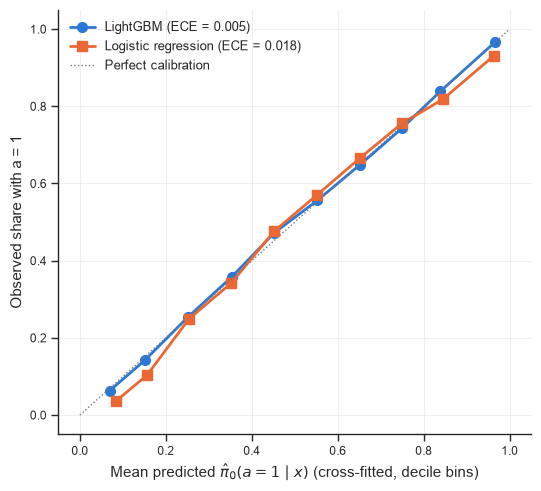

In [11]:
# @title 3-4. 傾向スコアの較正
e_logit, _, _ = crossfit_nuisance(data, X_POL_MAIN, 'Recidivism_Within_3years', ps_model='logit')

def ece(p, y, bins=10):
    idx = np.minimum((p * bins).astype(int), bins - 1)
    return sum(np.mean(idx == b) * abs(p[idx == b].mean() - y[idx == b].mean()) for b in range(bins) if np.any(idx == b))

calib_rows = {}
for name, e_hat in [('LightGBM', e_all), ('Logistic regression', e_logit)]:
    ec = np.clip(e_hat, 0.05, 0.95)
    calib_rows[name] = {'AUC': roc_auc_score(A, e_hat), 'Brier': brier_score_loss(A, e_hat), 'ECE (10 bins)': ece(e_hat, A),
                        'mean IPW weight A=1': np.mean(A / ec), 'mean IPW weight A=0': np.mean((1 - A) / (1 - ec)),
                        'share outside [0.05,0.95]': np.mean((e_hat < 0.05) | (e_hat > 0.95))}
calib = pd.DataFrame(calib_rows).T.round(4)
calib.to_csv(TAB / 'propensity_calibration.csv')
display(calib)

fig, ax = plt.subplots(figsize=(5.5, 5))
bins = np.linspace(0, 1, 11)
for name, e_hat, c, mk in [('LightGBM', e_all, C_BLUE, 'o'), ('Logistic regression', e_logit, C_ORANGE, 's')]:
    idx = np.minimum(np.digitize(e_hat, bins) - 1, 9)
    g = pd.DataFrame({'b': idx, 'e': e_hat, 'a': A}).groupby('b').agg(e=('e', 'mean'), a=('a', 'mean'), n=('a', 'size'))
    ax.plot(g.e, g.a, marker=mk, ms=7, lw=2, color=c, label=f'{name} (ECE = {calib.loc[name, "ECE (10 bins)"]:.3f})')
ax.plot([0, 1], [0, 1], color=C_GRAY, ls=':', lw=1, label='Perfect calibration')
ax.set_xlabel(r'Mean predicted $\hat\pi_0(a=1\mid x)$ (cross-fitted, decile bins)', fontsize=11)
ax.set_ylabel('Observed share with a = 1', fontsize=11)
ax.legend(fontsize=9, frameon=False, loc='upper left'); ax.grid(alpha=0.3); sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG / 'figA1_propensity_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# @title 3-5. リスクスコアは 56 変数の下で再逮捕の予測に情報を足すか（記述的な確認。予測への寄与が小さくても交絡がないことの証明にはならないので、スコアを含む仕様は頑健性チェック R7 で報告）
_, q0_a, q1_a = crossfit_nuisance(data, X_POL_MAIN, 'Recidivism_Within_3years')
_, q0_b, q1_b = crossfit_nuisance(data, X_POL_MAIN + RISK_VARS, 'Recidivism_Within_3years')
q_obs_a, q_obs_b = np.where(A == 1, q1_a, q0_a), np.where(A == 1, q1_b, q0_b)
risk_add = pd.Series({
    'AUC of q(x,a), 56 variables': roc_auc_score(data['Recidivism_Within_3years'], q_obs_a),
    'AUC of q(x,a), 56 variables + risk score': roc_auc_score(data['Recidivism_Within_3years'], q_obs_b),
    'AUC of pi0_hat, 56 variables': roc_auc_score(A, e_all),
}).round(4)
risk_add.to_csv(TAB / 'risk_score_added_value.csv')
display(risk_add)

AUC of q(x,a), 56 variables                 0.7336
AUC of q(x,a), 56 variables + risk score    0.7345
AUC of pi0_hat, 56 variables                0.7680
dtype: float64

## 4. 方策学習と評価の実装

`DRPolicyOptimizer.optimize_policy` は `notebooks/mjca_simdata.ipynb` からコピーし、**次の 2 点だけを修正**した（既存ノートは変更していない）。

1. **行の対応ずれ**: 既存コードは毎 epoch テンソルを累積的に並べ替える（`X = X[perm]`）一方で、`q_hat_A1/A0` は元の DataFrame から今回の `perm` だけで取り出している。そのため 2 epoch 目以降、DM 項が他人の $\hat q$ を使う。→ 毎 epoch、元の順序から並べ替えるように修正。
2. **統制群の傾向スコア**: 既存コードは重みを常に $\pi_\theta(a_i\mid x_i)/\hat e(x_i)$ としている（$\hat e = \hat P(A=1\mid x)$）。$A=0$ では分母が $1-\hat e(x_i)$ であるべき（論文式 (10)）。→ $\hat\pi_0(a_i\mid x_i)$ を使うように修正。

あわせて、propensity の clip 幅を引数にした（既定は既存と同じ $[0.05, 0.95]$）。

**比較する方策の定義**（処遇 = High/Specialized。$r$ は再逮捕なので小さいほど良い）

| 方策 | 定義 | 順位スコアとして使えるか |
|---|---|---|
| Case 1: MJCA 型 | $\hat q(x)=\hat E[r\mid x]$ が閾値以上なら処遇（容量一致） | ○（リスクの順位） |
| Case 2: DM | $\hat q(x,1)<\hat q(x,0)$ なら処遇 | ○（$\hat q(x,0)-\hat q(x,1)$） |
| Case 2b: DR-learner | $\hat b_{\rm DR}(x)>0$ なら処遇 | ○（$\hat b_{\rm DR}(x)$） |
| Case 3: DR-OPL | NN 方策 $\pi_\theta$ の 10 seed 平均が 0.5 以上なら処遇 | ×（容量制約なしで学習しており、出力の大きさはベネフィットの大きさを表さない） |

DR-learner: train 内 cross-fitted な $\hat e, \hat q_0, \hat q_1$ から、処遇による再逮捕の減少量 $Y(0)-Y(1)$ の DR pseudo-outcome

$$\hat\phi_i=\hat q_0(X_i)-\hat q_1(X_i)+\frac{1-A_i}{1-\hat e_i}\{Y_i-\hat q_0(X_i)\}-\frac{A_i}{\hat e_i}\{Y_i-\hat q_1(X_i)\}$$

を作り、方策の入力 $x$ で LightGBM 回帰して $\hat b_{\rm DR}(x)=\hat E[\hat\phi\mid X=x]$ を得る（$\hat e$ は $[0.05, 0.95]$ で clip）。

In [13]:
# @title 4-1. DR 方策勾配による方策学習（既存クラスを修正して流用）
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, 2), nn.Softmax(dim=1))

    def forward(self, x):
        return self.fc(x)


class DRPolicyOptimizer:
    def __init__(self, feature_cols):
        self.feature_cols = feature_cols

    def optimize_policy(self, train_data, num_epochs=100, batch_size=256, ps_clip=(0.05, 0.95), seed=SEED):
        set_seed(seed)
        self.policy_net = PolicyNetwork(input_dim=len(self.feature_cols))
        optimizer = optim.Adam(self.policy_net.parameters(), lr=0.01)

        X0 = torch.tensor(train_data[self.feature_cols].values, dtype=torch.float)
        A0 = torch.tensor(train_data['A'].values, dtype=torch.long)
        R0 = torch.tensor(train_data['R'].values, dtype=torch.float)
        e = np.clip(train_data['ps_hat'].values, *ps_clip)
        # 修正 2: 観測された処遇の傾向スコア π0(a_i|x_i)
        ps_a0 = torch.tensor(np.where(train_data['A'].values == 1, e, 1 - e), dtype=torch.float)
        q1_0 = torch.tensor(train_data['q_hat_A1'].values, dtype=torch.float)
        q0_0 = torch.tensor(train_data['q_hat_A0'].values, dtype=torch.float)
        qa_0 = torch.where(A0 == 1, q1_0, q0_0)

        n = len(train_data)
        num_batches = int(np.ceil(n / batch_size))
        for epoch in range(num_epochs):
            # 修正 1: 毎 epoch 元の順序から並べ替え、全テンソルを同じ perm で揃える
            perm = torch.tensor(np.random.permutation(n))
            X_t, A_t, R_t, ps_t, q1_t, q0_t, qa_t = (t[perm] for t in (X0, A0, R0, ps_a0, q1_0, q0_0, qa_0))
            for i in range(num_batches):
                sl = slice(i * batch_size, min((i + 1) * batch_size, n))
                optimizer.zero_grad()
                pi_probs = self.policy_net(X_t[sl])
                pi_a = pi_probs.gather(1, A_t[sl].view(-1, 1)).squeeze(1)
                # DR 推定量（論文式 (10)）。r は再犯なので最小化
                V_pi = ((pi_a / ps_t[sl]) * (R_t[sl] - qa_t[sl]) +
                        pi_probs[:, 1] * q1_t[sl] + pi_probs[:, 0] * q0_t[sl]).mean()
                V_pi.backward()
                optimizer.step()
        return self

    def predict_proba(self, data):
        with torch.no_grad():
            return self.policy_net(torch.tensor(data[self.feature_cols].values, dtype=torch.float)).numpy()[:, 1]

In [14]:
# @title 4-2. 方策価値の推定量（DR / SNIPS / DM）とブートストラップ
def top_k_score(score, k, seed=SEED):
    # score の上位 k 割を処遇（同点は乱数で分ける）
    n = len(score); m = int(round(k * n))
    tie = np.random.default_rng(seed).random(n)
    d = np.zeros(n)
    if m > 0:
        d[np.lexsort((-tie, -score))[:m]] = 1.0
    return d

def value_terms(p1, A, R, e, q0, q1, ps_clip=(0.05, 0.95)):
    # p1 = π(a=1|x)。個人ごとの DR・DM の寄与と IPS の重みを返す
    e = np.clip(e, *ps_clip)
    qd = p1 * q1 + (1 - p1) * q0
    qa = np.where(A == 1, q1, q0)
    w = np.where(A == 1, p1 / e, (1 - p1) / (1 - e))
    return {'DR': qd + w * (R - qa), 'DM': qd, 'w': w, 'wR': w * R}

def summarize_values(policies, A, R, e, q0, q1, ref='Case 1: MJCA', B=1000, ps_clip=(0.05, 0.95), seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(A)
    idx = rng.integers(0, n, size=(B, n))
    terms = {k: value_terms(p, A, R, e, q0, q1, ps_clip) for k, p in policies.items()}

    def stats(t):
        return {'DR': t['DR'].mean(), 'DM': t['DM'].mean(), 'SNIPS': t['wR'].sum() / t['w'].sum()}

    def boot_dr(t):
        return t['DR'][idx].mean(axis=1)

    rows, ref_boot = [], boot_dr(terms[ref])
    for k, t in terms.items():
        s, bd = stats(t), boot_dr(t)
        diff = bd - ref_boot
        rows.append({'policy': k, 'share_treated': policies[k].mean(),
                     'V_DR': s['DR'], 'DR_lo': np.percentile(bd, 2.5), 'DR_hi': np.percentile(bd, 97.5),
                     'V_SNIPS': s['SNIPS'], 'V_DM': s['DM'],
                     'diff_vs_MJCA': s['DR'] - terms[ref]['DR'].mean(),
                     'diff_lo': np.percentile(diff, 2.5), 'diff_hi': np.percentile(diff, 97.5)})
    return pd.DataFrame(rows).set_index('policy')

In [15]:
# @title 4-3. 1 仕様分の分析（学習: train、評価: test）
def run_spec(data, outcome='Recidivism_Within_3years', x_nuis=None, x_pol=None, ps_clip=(0.05, 0.95),
             trim=None, seeds=MAIN_SEEDS, B=1000, ps_model='lgb', return_details=False):
    x_nuis = x_pol if x_nuis is None else x_nuis  # 既定: 審判も方策と同じ特徴量（apples-to-apples）
    d = data.copy()
    d['R'] = d[outcome]
    tr, te = d[d.train == 1].copy(), d[d.train == 0].copy()

    # (a) 方策学習用 nuisance: train 内 cross-fitting。全手法で学習に使う情報をそろえるため x_pol を使う
    #     （MJCA 型 q(x) が使わない変数を DR 系の学習だけに使うと apples-to-apples にならない）
    tr['ps_hat'], tr['q_hat_A0'], tr['q_hat_A1'] = crossfit_nuisance(tr, x_pol, 'R', ps_model=ps_model)
    # (b) 評価用 nuisance（全方策に共通の「審判」）: test 内 cross-fitting。交絡調整のため x_nuis を使う
    e_ev, q0_ev, q1_ev = crossfit_nuisance(te, x_nuis, 'R', ps_model=ps_model)
    if trim is not None:  # overlap 外を除外（train・test ともに各自の cross-fitted ê で）
        tr = tr[(tr.ps_hat >= trim[0]) & (tr.ps_hat <= trim[1])].copy()
        m = (e_ev >= trim[0]) & (e_ev <= trim[1])
        te, e_ev, q0_ev, q1_ev = te[m].copy(), e_ev[m], q0_ev[m], q1_ev[m]

    # 方策の入力は x_pol（標準化は train で fit）
    mu, sd = tr[x_pol].mean(), tr[x_pol].std().replace(0, 1)
    Ztr, Zte = (tr[x_pol] - mu) / sd, (te[x_pol] - mu) / sd
    k_treat = tr['A'].mean()  # 容量 = train の観測処遇割合

    # Case 1: MJCA 型  q̂(x) = E[r|x] を閾値化（容量一致）
    m_mjca = fit_lgb(tr[x_pol], tr['R'])
    s_tr, s_te = m_mjca.predict(tr[x_pol]), m_mjca.predict(te[x_pol])
    thr = np.quantile(s_tr, 1 - k_treat)
    # Case 2: DM  q̂(x,a) = E[r|x,a]
    m_dm = fit_lgb(tr[x_pol].assign(A=tr['A'].values), tr['R'])
    dm1, dm0 = m_dm.predict(te[x_pol].assign(A=1)), m_dm.predict(te[x_pol].assign(A=0))
    dm_tr_gain = m_dm.predict(tr[x_pol].assign(A=0)) - m_dm.predict(tr[x_pol].assign(A=1))
    thr_dm = np.quantile(dm_tr_gain, 1 - k_treat)
    # Case 2b: DR-learner  b̂(x) = E[φ | x]。φ は Y(0)-Y(1)（処遇による再逮捕の減少量）の DR pseudo-outcome
    e_c = np.clip(tr['ps_hat'].values, *ps_clip)
    A_tr, R_tr = tr['A'].values, tr['R'].values
    q0_tr, q1_tr = tr['q_hat_A0'].values, tr['q_hat_A1'].values
    phi = (q0_tr - q1_tr) + (1 - A_tr) / (1 - e_c) * (R_tr - q0_tr) - A_tr / e_c * (R_tr - q1_tr)
    m_drl = lgb.train({'objective': 'regression', 'verbosity': -1, 'seed': SEED}, lgb.Dataset(tr[x_pol], phi), num_boost_round=100)
    b_tr, b_te = m_drl.predict(tr[x_pol]), m_drl.predict(te[x_pol])
    thr_drl = np.quantile(b_tr, 1 - k_treat)

    policies = {
        'Observed (pi0)': e_ev,  # ロギング方策 π̂0(a=1|x) を確率的方策として評価
        'Treat none': np.zeros(len(te)),
        'Treat all': np.ones(len(te)),
        'Case 1: MJCA': (s_te >= thr).astype(float),
        'Case 2: DM': (dm1 < dm0).astype(float),
        'Case 2: DM (capacity)': ((dm0 - dm1) >= thr_dm).astype(float),
        'Case 2b: DR-learner': (b_te > 0).astype(float),
        'Case 2b: DR-learner (capacity)': (b_te >= thr_drl).astype(float),
        # 付録用の外部ベンチマーク: Georgia の初回リスクスコア順に処遇（容量一致。同点はランダムに分ける）
        'Benchmark: Georgia risk score': top_k_score(te['risk_score'].values, k_treat),
    }
    # Case 3: DR-OPL（NN 方策）。定義は全図表で共通: 10 seed の π_θ(1|x) の平均が 0.5 以上なら処遇
    # （π_θ は容量制約なしで学習しているので、順位スコアとしては使わない）
    tr_pol = pd.concat([Ztr, tr[['A', 'R', 'ps_hat', 'q_hat_A0', 'q_hat_A1']]], axis=1)
    bs = max(200, min(2000, len(tr) // 10))
    case3_probs, case3_opts = [], []
    for s in seeds:
        opt = DRPolicyOptimizer(x_pol).optimize_policy(tr_pol, num_epochs=100, batch_size=bs, ps_clip=ps_clip, seed=s)
        case3_probs.append(opt.predict_proba(Zte))
        case3_opts.append(opt)
    case3_probs = np.array(case3_probs)
    policies['Case 3: DR-OPL'] = (case3_probs.mean(axis=0) >= 0.5).astype(float)

    A_te, R_te = te['A'].values, te['R'].values
    res = summarize_values(policies, A_te, R_te, e_ev, q0_ev, q1_ev, B=B, ps_clip=ps_clip)
    res.attrs['n_test'], res.attrs['observed_rate'] = len(te), R_te.mean()

    seed_rows = []  # 参考: seed ごとの NN 方策（seed 平均方策とは別物）
    for s, p in zip(seeds, case3_probs):
        pp = (p >= 0.5).astype(float)
        t = value_terms(pp, A_te, R_te, e_ev, q0_ev, q1_ev, ps_clip)
        seed_rows.append({'seed': s, 'share_treated': pp.mean(), 'V_DR': t['DR'].mean()})
    if not return_details:
        return res, pd.DataFrame(seed_rows)
    details = dict(te=te, tr=tr, e_ev=e_ev, q0_ev=q0_ev, q1_ev=q1_ev, s_te=s_te, dm1=dm1, dm0=dm0,
                   policies=policies, m_mjca=m_mjca, m_dm=m_dm, case3_probs=case3_probs, b_te=b_te, phi_tr=phi,
                   case3_opts=case3_opts, m_drl=m_drl, pol_mu=mu, pol_sd=sd, x_pol=x_pol)
    return res, pd.DataFrame(seed_rows), details

## 5. 主分析

- nuisance（$\hat\pi_0$, 評価用 $\hat q$）: 方策と同じ 56 変数（2026-09-29 改訂）
- 方策の入力（Case 1–3）: `black` を除く（計画 §2.5。結果を見る前に固定した本文仕様）。さらに `risk_score`・`risk_score_missing` も除く（2026-09-29 改訂）
  - Georgia の初回リスクスコアは、それ自体が既存の「MJCA 型」予測ツール。我々の $q(x)$ に入れると「既存の予測ツールの上に予測を重ねた」比較になるので、方策は生の特徴量だけで作る。スコアは付録で外部ベンチマーク（スコア順に処遇する方策）として示す
  - **学習に使う情報は全手法でそろえる**: DR-learner・DR-OPL の学習用 nuisance（train 側の $\hat\pi_0$, $\hat q$）も、方策入力と同じ特徴量だけで作る
  - **評価用 nuisance（test 側。全方策に共通の審判）も同じ 56 変数**（2026-09-29 改訂。以前は審判だけ Race とリスクスコアを加えていた）。リスクスコアは 56 変数の下で再逮捕の予測にほとんど情報を足さない（§3-5）。ただし予測への寄与が小さいことは交絡がないことの証明にはならないので、スコアを方策入力と審判の両方に含める仕様を頑健性チェック R7 として報告する

In [16]:
# @title 5-1. 主分析の実行
res_main, seeds_main, det = run_spec(data, x_pol=X_POL_MAIN, return_details=True)
res_main.round(4).to_csv(TAB / 'policy_values_main.csv')
seeds_main.to_csv(TAB / 'case3_seed_variation_main.csv', index=False)
print('n_test =', res_main.attrs['n_test'], '| observed 3y re-arrest rate (test) =', round(res_main.attrs['observed_rate'], 4))
display(res_main.round(4))
print('参考: seed ごとの NN 方策（主表の Case 3 は 10 seed の平均方策）')
display(seeds_main[['share_treated', 'V_DR']].agg(['mean', 'std', 'min', 'max']).round(4))

n_test = 7299 | observed 3y re-arrest rate (test) = 0.5699


,share_treated,V_DR,DR_lo,DR_hi,V_SNIPS,V_DM,diff_vs_MJCA,diff_lo,diff_hi
policy,,,,,,,,,
Observed (pi0),0.5867,0.5697,0.5579,0.5804,0.5698,0.5722,0.0039,-0.0105,0.0170
Treat none,0.0000,0.5343,0.5111,0.5552,0.5487,0.5436,-0.0316,-0.0564,-0.0095
Treat all,1.0000,0.5944,0.5752,0.6133,0.5962,0.5919,0.0286,0.0109,0.0457
Case 1: MJCA,0.5927,0.5659,0.5475,0.5848,0.5727,0.5740,0.0000,0.0000,0.0000
Case 2: DM,0.1958,0.5475,0.5250,0.5677,0.5616,0.5527,-0.0183,-0.0405,0.0016
Case 2: DM (capacity),0.5758,0.5678,0.5477,0.5875,0.5674,0.5697,0.0019,-0.0177,0.0211
Case 2b: DR-learner,0.3755,0.5539,0.5332,0.5742,0.5647,0.5614,-0.0120,-0.0327,0.0075
Case 2b: DR-learner (capacity),0.5934,0.5617,0.5404,0.5817,0.5665,0.5715,-0.0042,-0.0248,0.0146
Benchmark: Georgia risk score,0.5854,0.5655,0.5446,0.5893,0.5716,0.5740,-0.0003,-0.0195,0.0176


参考: seed ごとの NN 方策（主表の Case 3 は 10 seed の平均方策）


,share_treated,V_DR
mean,0.3145,0.5585
std,0.0505,0.0049
min,0.2372,0.5502
max,0.3927,0.5667


In [17]:
# @title 5-2. 推定量の健全性チェック
te, e_ev, q0_ev, q1_ev = det['te'], det['e_ev'], det['q0_ev'], det['q1_ev']
A_te, R_te = te['A'].values, te['R'].values
e_c = np.clip(e_ev, 0.05, 0.95)
sanity = pd.Series({
    'observed rate (test)': R_te.mean(),
    'V_DM(pi0_hat): q averaged over pi0_hat': (e_ev * q1_ev + (1 - e_ev) * q0_ev).mean(),
    'mean IPW weight, A=1 (should be ~1)': np.mean(A_te / e_c),
    'mean IPW weight, A=0 (should be ~1)': np.mean((1 - A_te) / (1 - e_c)),
    'V_DR(pi0_hat) - observed rate (should be ~0)': res_main.loc['Observed (pi0)', 'V_DR'] - R_te.mean(),
}).round(4)
sanity.to_csv(TAB / 'estimator_sanity.csv')
display(sanity)

observed rate (test)                            0.5699
V_DM(pi0_hat): q averaged over pi0_hat          0.5722
mean IPW weight, A=1 (should be ~1)             1.0334
mean IPW weight, A=0 (should be ~1)             1.0571
V_DR(pi0_hat) - observed rate (should be ~0)   -0.0002
dtype: float64

## 6. 予測性能の比較（論文 Fig. 2 に対応）

pi0_hat (A | x)    0.7610
q_MJCA (r | x)     0.7322
q_DM (r | x, a)    0.7331
dtype: float64

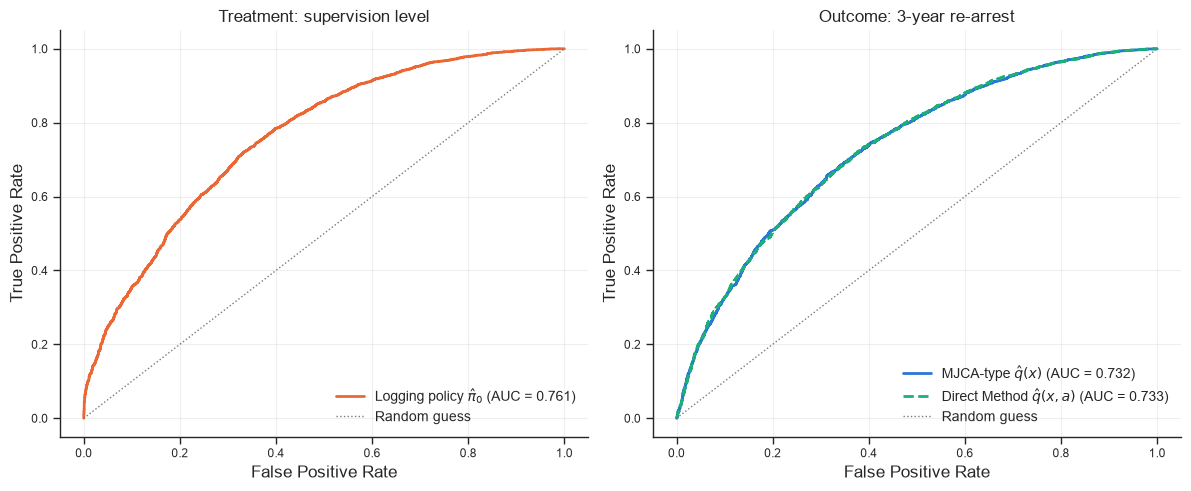

In [18]:
# @title 6-1. 図 2: ROC（π̂0、q̂(x) vs q̂(x,a)）
tr = det['tr']
m_ps_full = fit_lgb(tr[X_POL_MAIN], tr['A'])
ps_te = m_ps_full.predict(te[X_POL_MAIN])
q_obs = np.where(A_te == 1, det['dm1'], det['dm0'])

auc = pd.Series({
    'pi0_hat (A | x)': roc_auc_score(A_te, ps_te),
    'q_MJCA (r | x)': roc_auc_score(R_te, det['s_te']),
    'q_DM (r | x, a)': roc_auc_score(R_te, q_obs)}).round(4)
auc.to_csv(TAB / 'auc.csv')
display(auc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(A_te, ps_te)
axes[0].plot(fpr, tpr, color=C_ORANGE, lw=2, label=f'Logging policy $\\hat\\pi_0$ (AUC = {auc.iloc[0]:.3f})')
fpr, tpr, _ = roc_curve(R_te, det['s_te'])
axes[1].plot(fpr, tpr, color=C_BLUE, lw=2, label=f'MJCA-type $\\hat q(x)$ (AUC = {auc.iloc[1]:.3f})')
fpr, tpr, _ = roc_curve(R_te, q_obs)
axes[1].plot(fpr, tpr, color=C_AQUA, lw=2, ls='--', label=f'Direct Method $\\hat q(x,a)$ (AUC = {auc.iloc[2]:.3f})')
for ax in axes:
    ax.plot([0, 1], [0, 1], color=C_GRAY, ls=':', lw=1, label='Random guess')
    ax.set_xlabel('False Positive Rate', fontsize=12); ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(fontsize=10, frameon=False, loc='lower right'); ax.grid(alpha=0.3)
    sns.despine(ax=ax)
axes[0].set_title('Treatment: supervision level', fontsize=12)
axes[1].set_title('Outcome: 3-year re-arrest', fontsize=12)
plt.tight_layout()
plt.savefig(FIG / 'fig2_roc.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. 解釈可能な係数比較（論文 Appendix B / Table 3 に対応）

ロジスティック回帰 $r\sim x$ と $r\sim x + a$（train）。$a$ の係数は観察データ上の条件付き関連であり、因果効果ではない。

In [19]:
# @title 7-1. 表 2: 係数比較
trd = data[data.train == 1]
Xc = sm.add_constant(trd[X_POL_MAIN])
fit_x = sm.Logit(trd['Recidivism_Within_3years'], Xc).fit(disp=0)
fit_xa = sm.Logit(trd['Recidivism_Within_3years'], Xc.assign(A=trd['A'])).fit(disp=0)

coef = pd.DataFrame({'MJCA_coef': fit_x.params, 'MJCA_se': fit_x.bse,
                     'DM_coef': fit_xa.params, 'DM_se': fit_xa.bse}).round(3)
coef.to_csv(TAB / 'logit_coefficients_full.csv')
KEY = ['A', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_PPViolationCharges',
       'gang_affiliated', 'age_group', 'offense_Violent_Sex', 'Condition_MH_SA', 'male']
coef_key = coef.loc[KEY]
coef_key.to_csv(TAB / 'logit_coefficients_key.csv')
display(coef_key)

,MJCA_coef,MJCA_se,DM_coef,DM_se
A,NaN,NaN,0.168,0.038
Prior_Arrest_Episodes_Felony,0.067,0.012,0.065,0.012
Prior_Arrest_Episodes_PPViolationCharges,0.098,0.016,0.098,0.016
gang_affiliated,0.857,0.056,0.859,0.056
age_group,-0.308,0.012,-0.292,0.012
offense_Violent_Sex,-0.420,0.111,-0.479,0.112
Condition_MH_SA,0.284,0.039,0.289,0.039
male,0.445,0.054,0.450,0.054


## 8. 方策の比較（図 3・表 3・表 4）

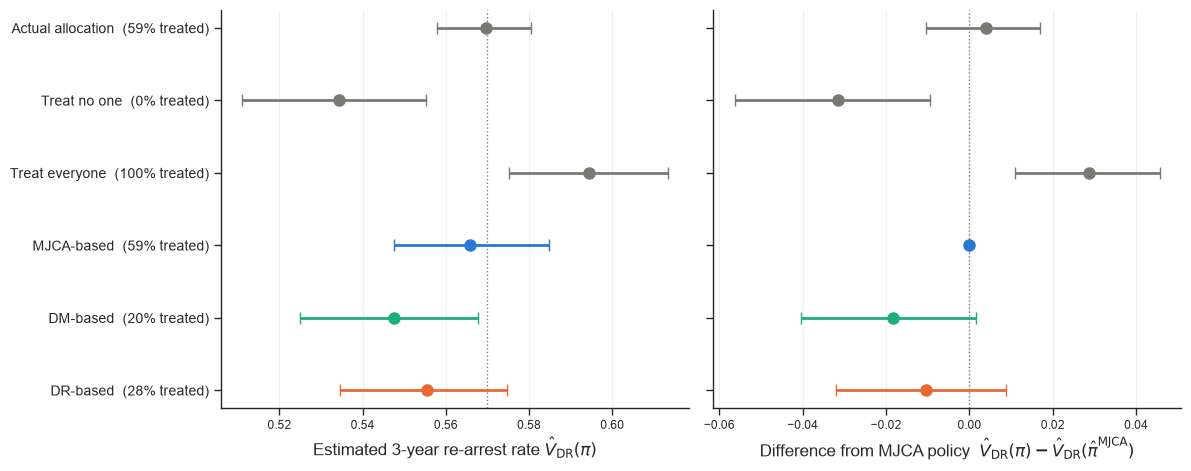

In [20]:
# @title 8-1. 図 3: 方策別の推定再逮捕率（DR、95% ブートストラップ CI）
# 処遇割合を自由にした方策のみ。容量をそろえた比較は図 4。DR 系は論文と同じく DR-OPL を主に示す（DR-learner は表のみ）
order = ['Observed (pi0)', 'Treat none', 'Treat all', 'Case 1: MJCA', 'Case 2: DM', 'Case 3: DR-OPL']
r = res_main.loc[order]
colors = [C_GRAY, C_GRAY, C_GRAY, C_BLUE, C_AQUA, C_ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
y = np.arange(len(order))[::-1]
for yi, (_, row), c in zip(y, r.iterrows(), colors):
    axes[0].errorbar(row.V_DR, yi, xerr=[[row.V_DR - row.DR_lo], [row.DR_hi - row.V_DR]], fmt='o', color=c, ms=8, capsize=4, lw=2)
    axes[1].errorbar(row.diff_vs_MJCA, yi, xerr=[[row.diff_vs_MJCA - row.diff_lo], [row.diff_hi - row.diff_vs_MJCA]],
                     fmt='o', color=c, ms=8, capsize=4, lw=2)
axes[0].axvline(res_main.attrs['observed_rate'], color=C_GRAY, ls=':', lw=1)
axes[1].axvline(0, color=C_GRAY, ls=':', lw=1)
# 論文と同じ呼び方で表示する
DISPLAY = {'Observed (pi0)': 'Actual allocation', 'Treat none': 'Treat no one', 'Treat all': 'Treat everyone',
           'Case 1: MJCA': 'MJCA-based', 'Case 2: DM': 'DM-based', 'Case 3: DR-OPL': 'DR-based'}
axes[0].set_yticks(y); axes[0].set_yticklabels([f'{DISPLAY.get(k, k)}  ({r.loc[k, "share_treated"]:.0%} treated)' for k in order], fontsize=10)
axes[0].set_xlabel(r'Estimated 3-year re-arrest rate $\hat V_{\mathrm{DR}}(\pi)$', fontsize=12)
axes[1].set_xlabel(r'Difference from MJCA policy  $\hat V_{\mathrm{DR}}(\pi)-\hat V_{\mathrm{DR}}(\hat\pi^{\mathrm{MJCA}})$', fontsize=12)
for ax in axes:
    ax.grid(axis='x', alpha=0.3); sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG / 'fig3_policy_values.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# @title 8-2. 表 4: 方策間の割当ての一致度と、リスク水準別の割当て
pol = det['policies']
pol_obs = {**pol, 'Observed (pi0)': te['A'].values.astype(float)}  # 一致度は実際の割当てで比較
agree = pd.DataFrame({k: [np.mean(pol_obs[k] == pol['Case 1: MJCA'])] for k in order + ['Case 2b: DR-learner', 'Case 2: DM (capacity)', 'Case 2b: DR-learner (capacity)'] if k != 'Case 1: MJCA'},
                     index=['agreement with Case 1: MJCA']).T.round(3)
agree.to_csv(TAB / 'policy_agreement.csv')
display(agree)

# 予測リスクの 5 分位ごとに、各方策が処遇する割合と DM の推定効果 q̂(x,1)-q̂(x,0)
risk_q = pd.qcut(det['s_te'], 5, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])
by_risk = pd.DataFrame({
    'n': pd.Series(risk_q).value_counts().sort_index().values,
    'observed_recid': pd.Series(R_te).groupby(risk_q, observed=True).mean().values,
    'DM_effect_q1_minus_q0': pd.Series(det['dm1'] - det['dm0']).groupby(risk_q, observed=True).mean().values,
    'DRL_effect_minus_b': pd.Series(-det['b_te']).groupby(risk_q, observed=True).mean().values,
    **{f'treated_{k}': pd.Series(pol_k[k]).groupby(risk_q, observed=True).mean().values
       for k, pol_k in [('Observed (pi0)', pol_obs), ('Case 1: MJCA', pol), ('Case 2: DM', pol), ('Case 2b: DR-learner', pol), ('Case 3: DR-OPL', pol)]}},
    index=risk_q.categories).round(3)
by_risk.to_csv(TAB / 'allocation_by_predicted_risk.csv')
display(by_risk)

,agreement with Case 1: MJCA
Observed (pi0),0.578
Treat none,0.407
Treat all,0.593
Case 2: DM,0.431
Case 3: DR-OPL,0.470
Case 2b: DR-learner,0.489
Case 2: DM (capacity),0.501
Case 2b: DR-learner (capacity),0.522


,n,observed_recid,DM_effect_q1_minus_q0,DRL_effect_minus_b,treated_Observed (pi0),treated_Case 1: MJCA,treated_Case 2: DM,treated_Case 2b: DR-learner,treated_Case 3: DR-OPL
Q1 (lowest),1460,0.263,0.020,0.037,0.489,0.000,0.244,0.373,0.283
Q2,1460,0.460,0.034,0.040,0.532,0.000,0.182,0.351,0.259
Q3,1459,0.602,0.033,0.041,0.600,0.964,0.186,0.369,0.290
Q4,1460,0.703,0.029,0.035,0.624,1.000,0.187,0.378,0.274
Q5 (highest),1460,0.821,0.023,0.034,0.692,1.000,0.180,0.407,0.309


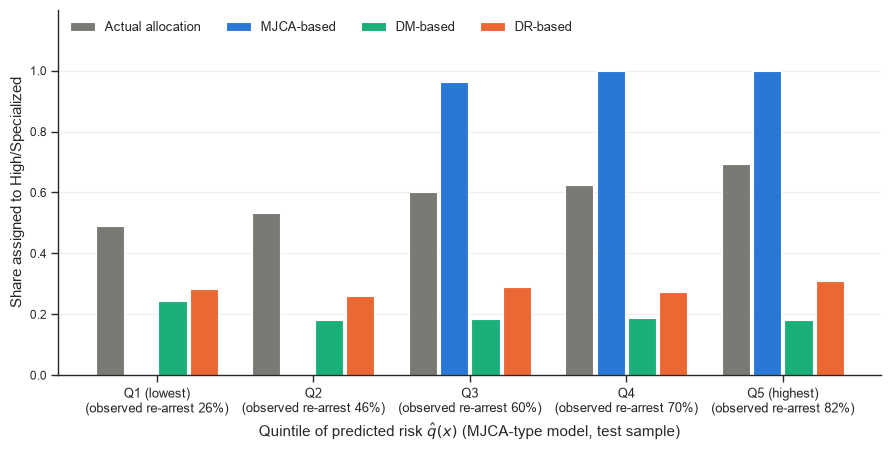

In [22]:
# @title 8-2b. 図 5: 予測リスクの 5 分位ごとの処遇割合（割当ての違い）
alloc_pols = [('Actual allocation', 'treated_Observed (pi0)', C_GRAY), ('MJCA-based', 'treated_Case 1: MJCA', C_BLUE),
              ('DM-based', 'treated_Case 2: DM', C_AQUA), ('DR-based', 'treated_Case 3: DR-OPL', C_ORANGE)]
fig, ax = plt.subplots(figsize=(9, 4.6))
xq = np.arange(len(by_risk))
w = 0.2
for i, (lab, col, c) in enumerate(alloc_pols):
    ax.bar(xq + (i - 1.5) * w, by_risk[col].values, width=w * 0.9, color=c, label=lab)
ax.set_xticks(xq)
ax.set_xticklabels([f'{q}\n(observed re-arrest {r:.0%})' for q, r in zip(by_risk.index, by_risk['observed_recid'])], fontsize=9)
ax.set_xlabel('Quintile of predicted risk $\\hat q(x)$ (MJCA-type model, test sample)', fontsize=11)
ax.set_ylabel('Share assigned to High/Specialized', fontsize=11)
ax.set_ylim(0, 1.2); ax.set_yticks(np.arange(0, 1.01, 0.2)); ax.grid(axis='y', alpha=0.3); sns.despine(ax=ax)
ax.legend(fontsize=9, frameon=False, ncol=4, loc='upper left')
plt.tight_layout()
plt.savefig(FIG / 'fig5_allocation_by_risk.png', dpi=300, bbox_inches='tight')
plt.show()

### 8-3. 処遇容量カーブ: 同じ人数を処遇するとき、「誰を選ぶか」で差が出るか

方策 3 種（リスク順 / DM 順 / DR-learner 順）で、test の上位 k% を処遇する（k = 0, 10, …, 100%）。3 つとも「順位スコア」として学習されたものだけを使う。

- リスク順: $\hat q^{\text{MJCA}}(x)$ の高い順（MJCA 型）
- DM 順: 推定ベネフィット $\hat q(x,0)-\hat q(x,1)$ の大きい順
- DR-learner 順: DR pseudo-outcome を回帰した推定ベネフィット $\hat b_{\rm DR}(x)$ の大きい順（§4 参照）
- NN 方策（DR-OPL）の $\pi_\theta(a=1\mid x)$ は容量制約なしで学習しており、大きさがベネフィットの大きさを表す保証がない。そのため順位スコアには使わず、DR に基づく順位付けとして DR-learner を使う（DR-OPL は処遇するかどうかの判断だけを出す）
- 参照: ランダム割当て（処遇確率 k の確率的方策。DR 推定量は $\pi$ について線形なので、「処遇しない」と「全員処遇」の線形補間になる）

k = 0% と 100% では全方策が一致する。右図は、リスク順との差の paired ブートストラップ 95% CI。

policy,Benchmark: Georgia risk score,DM ranking,DR-learner ranking,Random allocation,Risk ranking (MJCA-type)
capacity,,,,,
0.0,0.5343,0.5343,0.5343,0.5343,0.5343
0.1,0.5386,0.5441,0.5476,0.5403,0.5356
0.2,0.5471,0.5491,0.5465,0.5463,0.5433
0.3,0.5588,0.5540,0.5507,0.5523,0.5536
0.4,0.5659,0.5599,0.5522,0.5583,0.5592
0.5,0.5599,0.5689,0.5570,0.5643,0.5649
0.6,0.5653,0.5695,0.5629,0.5704,0.5679
0.7,0.5682,0.5733,0.5696,0.5764,0.5748
0.8,0.5754,0.5831,0.5804,0.5824,0.5835


policy,Benchmark: Georgia risk score,DM ranking,DR-learner ranking,Random allocation,Risk ranking (MJCA-type)
capacity,,,,,
0.0,0.0000,0.0000,0.0000,0.0000,0.0
0.1,0.0030,0.0085,0.0120,0.0047,0.0
0.2,0.0038,0.0058,0.0032,0.0030,0.0
0.3,0.0052,0.0005,-0.0028,-0.0013,0.0
0.4,0.0066,0.0007,-0.0071,-0.0009,0.0
0.5,-0.0050,0.0041,-0.0078,-0.0005,0.0
0.6,-0.0026,0.0016,-0.0050,0.0024,0.0
0.7,-0.0065,-0.0015,-0.0052,0.0016,0.0
0.8,-0.0080,-0.0004,-0.0031,-0.0011,0.0


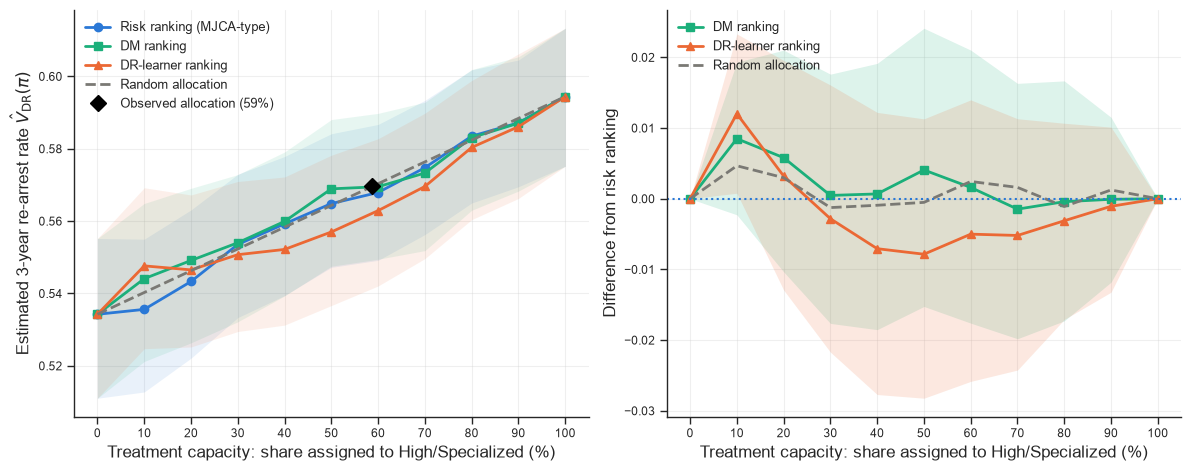

In [23]:
# @title 8-3. 図 4: 処遇容量カーブ
CAPS = np.round(np.arange(0, 1.01, 0.1), 2)
rank_scores = {
    'Risk ranking (MJCA-type)': det['s_te'],
    'DM ranking': det['dm0'] - det['dm1'],
    'DR-learner ranking': det['b_te'],
}

def top_k(score, k):
    n = len(score); m = int(round(k * n))
    d = np.zeros(n)
    if m > 0:
        d[np.argsort(-score, kind='stable')[:m]] = 1.0
    return d

rng = np.random.default_rng(SEED)
boot_idx = rng.integers(0, len(A_te), size=(1000, len(A_te)))
rows = []
for k in CAPS:
    dr_ref = value_terms(top_k(rank_scores['Risk ranking (MJCA-type)'], k), A_te, R_te, e_ev, q0_ev, q1_ev)['DR']
    ref_boot = dr_ref[boot_idx].mean(axis=1)
    pols = {**{name: top_k(sc, k) for name, sc in rank_scores.items()}, 'Random allocation': np.full(len(A_te), k),
            'Benchmark: Georgia risk score': top_k_score(te['risk_score'].values, k)}
    for name, p in pols.items():
        dr = value_terms(p, A_te, R_te, e_ev, q0_ev, q1_ev)['DR']
        b = dr[boot_idx].mean(axis=1)
        diff = b - ref_boot
        rows.append({'capacity': k, 'policy': name, 'V_DR': dr.mean(),
                     'lo': np.percentile(b, 2.5), 'hi': np.percentile(b, 97.5),
                     'diff_vs_risk': dr.mean() - dr_ref.mean(),
                     'diff_lo': np.percentile(diff, 2.5), 'diff_hi': np.percentile(diff, 97.5)})
cap_curve = pd.DataFrame(rows)
cap_curve.round(4).to_csv(TAB / 'capacity_curve.csv', index=False)
display(cap_curve.pivot(index='capacity', columns='policy', values='V_DR').round(4))
display(cap_curve.pivot(index='capacity', columns='policy', values='diff_vs_risk').round(4))

# 図
styles = {'Risk ranking (MJCA-type)': (C_BLUE, '-', 'o'), 'DM ranking': (C_AQUA, '-', 's'),
          'DR-learner ranking': (C_ORANGE, '-', '^'), 'Random allocation': (C_GRAY, '--', None)}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for name, (c, ls, mk) in styles.items():
    g = cap_curve[cap_curve.policy == name]
    axes[0].plot(g.capacity * 100, g.V_DR, color=c, ls=ls, marker=mk, ms=6, lw=2, label=name)
    if name != 'Random allocation':
        axes[0].fill_between(g.capacity * 100, g.lo, g.hi, color=c, alpha=0.10, lw=0)
    if name != 'Risk ranking (MJCA-type)':
        axes[1].plot(g.capacity * 100, g.diff_vs_risk, color=c, ls=ls, marker=mk, ms=6, lw=2, label=name)
        if name != 'Random allocation':
            axes[1].fill_between(g.capacity * 100, g.diff_lo, g.diff_hi, color=c, alpha=0.15, lw=0)
obs_share = A_te.mean()
axes[0].plot(obs_share * 100, res_main.loc['Observed (pi0)', 'V_DR'], marker='D', ms=8, color='k', ls='none',
             label=f'Observed allocation ({obs_share:.0%})')
axes[1].axhline(0, color=C_BLUE, ls=':', lw=1.5)
axes[0].set_ylabel(r'Estimated 3-year re-arrest rate $\hat V_{\mathrm{DR}}(\pi)$', fontsize=12)
axes[1].set_ylabel('Difference from risk ranking', fontsize=12)
for ax in axes:
    ax.set_xlabel('Treatment capacity: share assigned to High/Specialized (%)', fontsize=12)
    ax.set_xticks(CAPS * 100); ax.grid(alpha=0.3); sns.despine(ax=ax)
    ax.legend(fontsize=9, frameon=False, loc='upper left')
plt.tight_layout()
plt.savefig(FIG / 'fig4_capacity_curve.png', dpi=300, bbox_inches='tight')
plt.show()

### 8-4. 付録: Georgia の初回リスクスコアとの比較（外部ベンチマーク）

Georgia の初回リスクスコア（1–10）順に処遇する方策を、我々の MJCA 型 $q(x)$（生の特徴量のみ）と同じ容量で比べる。スコアは同点が多いので、同点の中は乱数で分ける。記述的な比較であり、主分析には使わない。

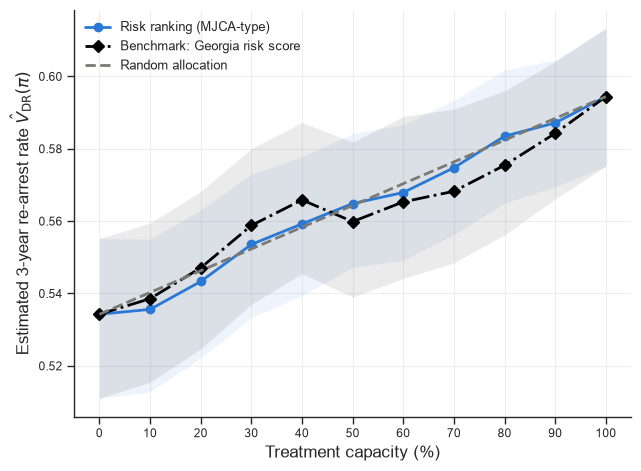

AUC of Georgia risk score for 3-year re-arrest (test): 0.607


In [24]:
# @title 8-4. 図 A2: Georgia リスクスコア順 vs MJCA 型 q(x) 順
fig, ax = plt.subplots(figsize=(6.5, 4.8))
for name, (c, ls, mk) in [('Risk ranking (MJCA-type)', (C_BLUE, '-', 'o')), ('Benchmark: Georgia risk score', ('k', '-.', 'D')),
                          ('Random allocation', (C_GRAY, '--', None))]:
    g = cap_curve[cap_curve.policy == name]
    ax.plot(g.capacity * 100, g.V_DR, color=c, ls=ls, marker=mk, ms=6, lw=2, label=name)
    if name != 'Random allocation':
        ax.fill_between(g.capacity * 100, g.lo, g.hi, color=c, alpha=0.08, lw=0)
ax.set_xlabel('Treatment capacity (%)', fontsize=12)
ax.set_ylabel(r'Estimated 3-year re-arrest rate $\hat V_{\mathrm{DR}}(\pi)$', fontsize=12)
ax.set_xticks(CAPS * 100); ax.grid(alpha=0.3); ax.legend(fontsize=9, frameon=False, loc='upper left'); sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG / 'figA2_georgia_score_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()
print('AUC of Georgia risk score for 3-year re-arrest (test):', round(roc_auc_score(R_te, te['risk_score']), 3))

### 8-5. 各モデルは何を見て人を分けているか（SHAP）と、その異質性は本物か

4 つのスコアを、同じ test のサンプル（1,000 人）で SHAP により分解する。

| スコア | 意味 | 値が大きいほど |
|---|---|---|
| MJCA 型 $\hat q(x)$ | 予測リスク | 再逮捕リスクが高い |
| DM $\hat q(x,0)-\hat q(x,1)$ | 推定ベネフィット | 処遇で再逮捕が減る |
| DR-learner $\hat b_{\rm DR}(x)$ | 推定ベネフィット（DR） | 処遇で再逮捕が減る |
| DR-OPL $\pi_\theta(1\mid x)$ | 処遇確率（10 seed 平均） | 処遇に割り当てる |

- SHAP は permutation 法（背景データは train から 100 人）。確率スケールで分解する。PUMA（24 ダミー）と罪種（5 ダミー）は、ダミーの SHAP を合計して 1 変数として扱う
- あわせて、(i) seed 間で DR-OPL の判断がどれだけ一致するか、(ii) 4 スコアの順位相関、(iii) スコアの 5 分位ごとに **評価用 nuisance（審判）の DR pseudo-outcome** で処遇効果を推定し、スコアが本当に効果の大小を分けているか、を確認する

In [25]:
# @title 8-5a. SHAP による分解
try:
    import shap
except ImportError:  # Colab などで未インストールの場合
    import subprocess as _sp
    _sp.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'], check=True)
    import shap

tr_d, te_d, xp = det['tr'], det['te'], det['x_pol']
mu_p, sd_p = det['pol_mu'], det['pol_sd']
nets = [o.policy_net for o in det['case3_opts']]

def f_mjca(Xa):
    return det['m_mjca'].predict(pd.DataFrame(Xa, columns=xp))

def f_dm_benefit(Xa):
    Xd = pd.DataFrame(Xa, columns=xp)
    return det['m_dm'].predict(Xd.assign(A=0)) - det['m_dm'].predict(Xd.assign(A=1))

def f_drl(Xa):
    return det['m_drl'].predict(pd.DataFrame(Xa, columns=xp))

def f_opl(Xa):
    Z = torch.tensor(((pd.DataFrame(Xa, columns=xp) - mu_p) / sd_p).values, dtype=torch.float)
    with torch.no_grad():
        return np.mean([net(Z).numpy()[:, 1] for net in nets], axis=0)

rng_s = np.random.default_rng(SEED)
X_explain = te_d[xp].iloc[rng_s.choice(len(te_d), 1000, replace=False)]
X_bg = tr_d[xp].iloc[rng_s.choice(len(tr_d), 100, replace=False)]

score_fns = {'MJCA risk q(x)': f_mjca, 'DM benefit': f_dm_benefit, 'DR-learner benefit': f_drl, 'DR-OPL pi(1|x)': f_opl}
shap_vals = {}
for name, fn in score_fns.items():
    expl = shap.explainers.Permutation(fn, shap.maskers.Independent(X_bg.values), seed=SEED)
    shap_vals[name] = expl(X_explain.values, max_evals=2 * len(xp) + 1).values

# ダミーをグループにまとめる
def group_of(c):
    if c.startswith('puma_'):
        return 'Residence PUMA'
    if c.startswith('offense_'):
        return 'Prison offense'
    return c
groups = pd.Series([group_of(c) for c in xp], index=xp)
# グループの SHAP = ダミーの SHAP の合計。重要度 = その絶対値の平均
imp = pd.DataFrame({name: pd.DataFrame(v, columns=xp).T.groupby(groups).sum().T.abs().mean()
                    for name, v in shap_vals.items()})
imp_share = (imp / imp.sum()).round(3)
imp.round(5).to_csv(TAB / 'shap_importance_by_group.csv')
imp_share.to_csv(TAB / 'shap_importance_share_by_group.csv')
display(imp_share.sort_values('DR-OPL pi(1|x)', ascending=False).head(12))
print('各スコアの SD（説明対象 1,000 人）:', {k: round(float(np.std(fn(X_explain.values))), 4) for k, fn in score_fns.items()})

/private/tmp/claude-503/-Users-hdymacuser-Develop-commentary-mjca/9d919d7f-ae99-427e-8be6-6b9d30517715/scratchpad/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PermutationExplainer explainer:  74%|███████▍  | 740/1000 [00:00<?, ?it/s]

PermutationExplainer explainer:  75%|███████▌  | 752/1000 [00:10<00:02, 113.69it/s]

PermutationExplainer explainer:  76%|███████▋  | 765/1000 [00:10<00:01, 117.81it/s]

PermutationExplainer explainer:  78%|███████▊  | 777/1000 [00:10<00:01, 118.37it/s]

...

PermutationExplainer explainer:  99%|█████████▉| 988/1000 [00:16<00:00, 64.50it/s]

PermutationExplainer explainer: 100%|█████████▉| 995/1000 [00:16<00:00, 64.15it/s]

PermutationExplainer explainer: 1001it [00:16, 24.53it/s]                         

,MJCA risk q(x),DM benefit,DR-learner benefit,DR-OPL pi(1|x)
Residence PUMA,0.035,0.080,0.105,0.203
Prison offense,0.021,0.038,0.052,0.093
Prior_Conviction_Episodes_Felony,0.009,0.019,0.043,0.069
Prior_Arrest_Episodes_GunCharges,0.007,0.009,0.031,0.056
prison_years,0.062,0.054,0.042,0.052
Condition_MH_SA,0.050,0.084,0.021,0.047
Condition_Other,0.010,0.054,0.030,0.045
Prior_Arrest_Episodes_Violent,0.015,0.028,0.061,0.042
Prior_Arrest_Episodes_PPViolationCharges,0.086,0.056,0.047,0.041
Prior_Revocations_Probation,0.010,0.022,0.009,0.034


各スコアの SD（説明対象 1,000 人）: {'MJCA risk q(x)': 0.2083, 'DM benefit': 0.0356, 'DR-learner benefit': 0.1469, 'DR-OPL pi(1|x)': 0.3237}


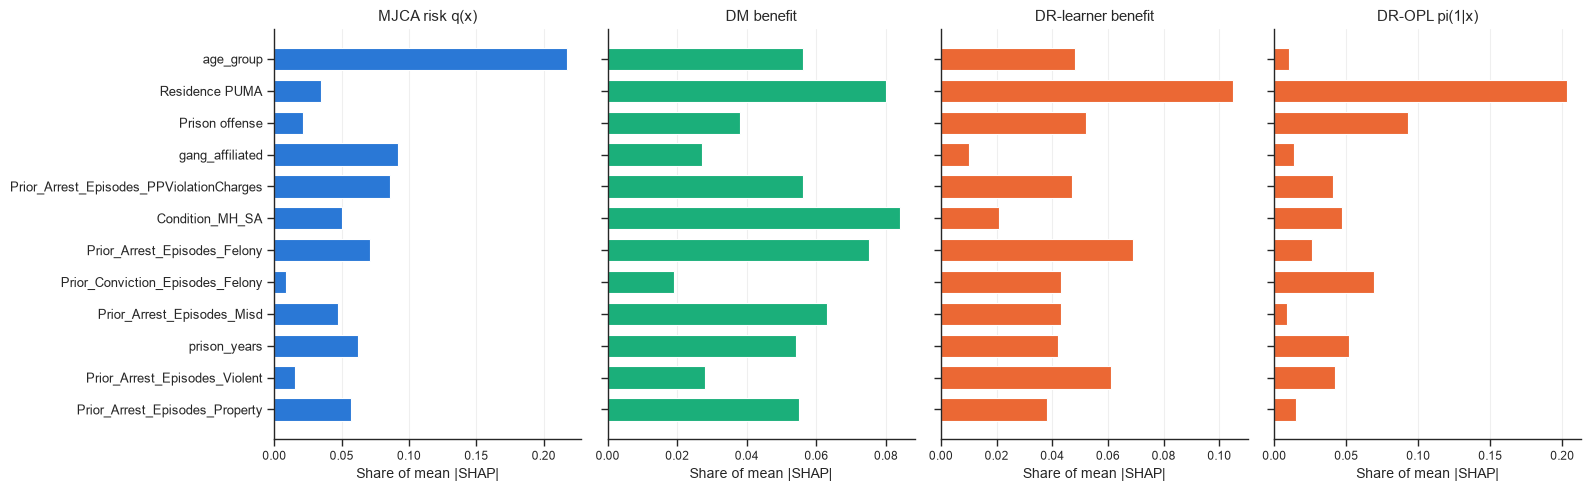

/var/folders/mw/pnqx3wj174l00ydjcqyddgth0000gq/T/ipykernel_7205/846421682.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals['DR-OPL pi(1|x)'], X_explain, max_display=10, show=False, plot_size=(7, 5))


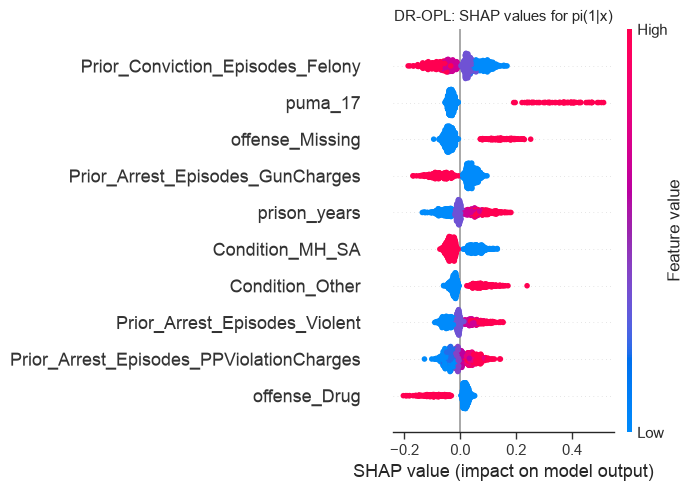

In [26]:
# @title 8-5b. 図 A4: 4 スコアの SHAP 重要度（上位 10 グループ、スコアの SHAP 合計に対する割合）
top = imp_share.max(axis=1).sort_values(ascending=False).head(12).index
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, (name, c) in zip(axes, [('MJCA risk q(x)', C_BLUE), ('DM benefit', C_AQUA),
                                 ('DR-learner benefit', C_ORANGE), ('DR-OPL pi(1|x)', C_ORANGE)]):
    vals = imp_share.loc[top, name]
    ax.barh(np.arange(len(top))[::-1], vals.values, color=c, height=0.7)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Share of mean |SHAP|', fontsize=10)
    ax.grid(axis='x', alpha=0.3); sns.despine(ax=ax)
axes[0].set_yticks(np.arange(len(top))[::-1]); axes[0].set_yticklabels(top, fontsize=9)
plt.tight_layout()
plt.savefig(FIG / 'figA4_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# DR-OPL の beeswarm（上位 10 特徴、ダミーは個別）
shap.summary_plot(shap_vals['DR-OPL pi(1|x)'], X_explain, max_display=10, show=False, plot_size=(7, 5))
plt.title('DR-OPL: SHAP values for pi(1|x)', fontsize=11)
plt.tight_layout()
plt.savefig(FIG / 'figA5_shap_beeswarm_dropl.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# @title 8-5c. seed 間の一致度とスコア間の順位相関
from scipy.stats import spearmanr
P = det['case3_probs']  # seeds × n_test
dec = (P >= 0.5).astype(int)
pair_agree = [np.mean(dec[i] == dec[j]) for i in range(len(P)) for j in range(i + 1, len(P))]
pair_rho = [spearmanr(P[i], P[j])[0] for i in range(len(P)) for j in range(i + 1, len(P))]
print(f'DR-OPL seed 間: 判断の一致率 平均 {np.mean(pair_agree):.3f}（範囲 {np.min(pair_agree):.3f}–{np.max(pair_agree):.3f}）,'
      f' π の順位相関 平均 {np.mean(pair_rho):.3f}（範囲 {np.min(pair_rho):.3f}–{np.max(pair_rho):.3f}）')

scores_te = pd.DataFrame({'MJCA risk q(x)': det['s_te'], 'DM benefit': det['dm0'] - det['dm1'],
                          'DR-learner benefit': det['b_te'], 'DR-OPL pi(1|x)': P.mean(axis=0)})
rank_corr = scores_te.corr(method='spearman').round(3)
rank_corr.to_csv(TAB / 'score_rank_correlation.csv')
display(rank_corr)

DR-OPL seed 間: 判断の一致率 平均 0.752（範囲 0.667–0.811）, π の順位相関 平均 0.594（範囲 0.403–0.789）


,MJCA risk q(x),DM benefit,DR-learner benefit,DR-OPL pi(1|x)
MJCA risk q(x),1.000,-0.024,0.025,0.045
DM benefit,-0.024,1.000,0.296,0.381
DR-learner benefit,0.025,0.296,1.000,0.358
DR-OPL pi(1|x),0.045,0.381,0.358,1.000


score,DM benefit,DR-OPL pi(1|x),DR-learner benefit,MJCA risk q(x)
quintile,,,,
1,0.057,0.078,0.070,0.055
2,0.068,0.039,0.087,0.078
3,0.048,0.034,0.054,0.043
4,0.054,0.053,0.028,0.080
5,0.074,0.097,0.061,0.045
Q5-Q1,0.018,0.019,-0.009,-0.009


,score,quintile,n,effect,lo,hi
5,MJCA risk q(x),Q5-Q1,NaN,-0.009,-0.093,0.077
11,DM benefit,Q5-Q1,NaN,0.018,-0.076,0.108
17,DR-learner benefit,Q5-Q1,NaN,-0.009,-0.104,0.076
23,DR-OPL pi(1|x),Q5-Q1,NaN,0.019,-0.069,0.110


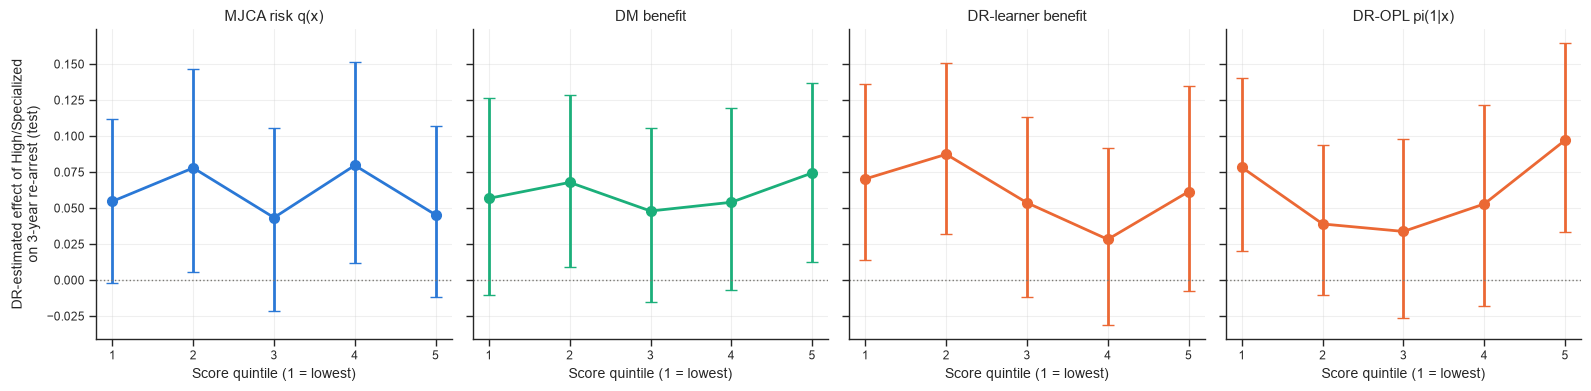

In [28]:
# @title 8-5d. 異質性の検証: スコアの 5 分位ごとの処遇効果（審判の DR pseudo-outcome で推定）
e_c = np.clip(e_ev, 0.05, 0.95)
# 処遇による再逮捕の変化 τ = Y(1) - Y(0) の DR pseudo-outcome（プラスほど処遇で再逮捕が増える）
tau_te = (q1_ev - q0_ev) + A_te / e_c * (R_te - q1_ev) - (1 - A_te) / (1 - e_c) * (R_te - q0_ev)
rng_g = np.random.default_rng(SEED)
bidx = rng_g.integers(0, len(A_te), size=(1000, len(A_te)))
rows = []
for name in scores_te.columns:
    qg = pd.qcut(scores_te[name].rank(method='first'), 5, labels=False).values
    for g in range(5):
        m = qg == g
        boot = np.array([tau_te[b][m[b]].mean() for b in bidx[:, :]])
        rows.append({'score': name, 'quintile': g + 1, 'n': m.sum(), 'effect': tau_te[m].mean(),
                     'lo': np.percentile(boot, 2.5), 'hi': np.percentile(boot, 97.5)})
    top_minus_bottom = np.array([tau_te[b][qg[b] == 4].mean() - tau_te[b][qg[b] == 0].mean() for b in bidx])
    rows.append({'score': name, 'quintile': 'Q5-Q1', 'n': np.nan,
                 'effect': tau_te[qg == 4].mean() - tau_te[qg == 0].mean(),
                 'lo': np.percentile(top_minus_bottom, 2.5), 'hi': np.percentile(top_minus_bottom, 97.5)})
gates = pd.DataFrame(rows)
gates.round(4).to_csv(TAB / 'heterogeneity_validation_by_score.csv', index=False)
display(gates.pivot(index='quintile', columns='score', values='effect').round(3))
display(gates[gates.quintile == 'Q5-Q1'].round(3))

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, name, c in zip(axes, scores_te.columns, [C_BLUE, C_AQUA, C_ORANGE, C_ORANGE]):
    g = gates[(gates.score == name) & (gates.quintile != 'Q5-Q1')]
    ax.errorbar(g.quintile.astype(int), g.effect, yerr=[g.effect - g.lo, g.hi - g.effect], fmt='o-', color=c, ms=7, capsize=4, lw=2)
    ax.axhline(0, color=C_GRAY, ls=':', lw=1)
    ax.set_title(name, fontsize=11); ax.set_xlabel('Score quintile (1 = lowest)', fontsize=10)
    ax.set_xticks(range(1, 6)); ax.grid(alpha=0.3); sns.despine(ax=ax)
axes[0].set_ylabel('DR-estimated effect of High/Specialized\non 3-year re-arrest (test)', fontsize=10)
plt.tight_layout()
plt.savefig(FIG / 'figA6_heterogeneity_validation.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# @title 8-5e. DR-OPL が強く使う部分集団の効果は、train と test で再現するか
e_tr_c = np.clip(tr_d['ps_hat'].values, 0.05, 0.95)
A_tr_d, R_tr_d = tr_d['A'].values, tr_d['R'].values
q0_tr_d, q1_tr_d = tr_d['q_hat_A0'].values, tr_d['q_hat_A1'].values
tau_tr = (q1_tr_d - q0_tr_d) + A_tr_d / e_tr_c * (R_tr_d - q1_tr_d) - (1 - A_tr_d) / (1 - e_tr_c) * (R_tr_d - q0_tr_d)

def sub_effect(tau, mask, B=1000, seed=SEED):
    rng_ = np.random.default_rng(seed)
    t = tau[mask]
    b = np.array([t[rng_.integers(0, len(t), len(t))].mean() for _ in range(B)])
    return t.mean(), np.percentile(b, 2.5), np.percentile(b, 97.5)

rows = []
for label, col in [('PUMA 17', 'puma_17'), ('Prison offense missing', 'offense_Missing')]:
    for split, dd, tau in [('train (learning nuisance)', tr_d, tau_tr), ('test (evaluator)', te_d, tau_te)]:
        for grp, m in [(label, dd[col].values == 1), ('others', dd[col].values == 0)]:
            est, lo, hi = sub_effect(tau, m)
            rows.append({'subgroup': label, 'split': split, 'group': grp, 'n': int(m.sum()), 'effect': est, 'lo': lo, 'hi': hi})
sub_rep = pd.DataFrame(rows)
sub_rep.round(4).to_csv(TAB / 'dropl_subgroup_replication.csv', index=False)
display(sub_rep.round(3))

,subgroup,split,group,n,effect,lo,hi
0,PUMA 17,train (learning nuisance),PUMA 17,1109,-0.056,-0.115,0.001
1,PUMA 17,train (learning nuisance),others,15707,0.042,0.024,0.059
2,PUMA 17,test (evaluator),PUMA 17,509,0.121,0.013,0.233
3,PUMA 17,test (evaluator),others,6790,0.056,0.029,0.088
4,Prison offense missing,train (learning nuisance),Prison offense missing,2162,-0.013,-0.063,0.033
5,Prison offense missing,train (learning nuisance),others,14654,0.043,0.026,0.061
6,Prison offense missing,test (evaluator),Prison offense missing,899,0.087,-0.001,0.177
7,Prison offense missing,test (evaluator),others,6400,0.056,0.027,0.088


## 9. 頑健性チェック（計画 §3.8）

各仕様ですべてのモデルを再学習する。Case 3 は主分析と同じく 10 seed の平均方策。

- R1: アウトカムを 1 年以内の逮捕に変更
- R2: propensity の clip を $[0.01, 0.99]$ に変更 / R2b: $\hat e \notin [0.05, 0.95]$ を trimming
- R3: 代替処遇 `Condition_MH_SA`（他の条件は共変量に残す）
- R4: High vs Standard のみ（Specialized を除外）。EDA で Specialized が罪種（性犯罪）でほぼ決まる別種の処遇だと分かったため追加（計画からの小さな逸脱。§11 に記録）
- R5 (a): `black` を方策入力に含める / R5 (b): `black`・`male` を方策入力から除く（計画 §2.5 の Appendix 版）
- R6: 傾向スコアをロジスティック回帰で推定（§3-4 参照）
- R7: Georgia のリスクスコアを方策入力（と学習用 nuisance）に含める（2026-09-29 改訂前の主仕様）

In [30]:
# @title 9-1. 頑健性チェックの実行
def headline(res, name):
    keys = ['Observed (pi0)', 'Case 1: MJCA', 'Case 2: DM', 'Case 2: DM (capacity)',
            'Case 2b: DR-learner', 'Case 2b: DR-learner (capacity)', 'Case 3: DR-OPL']
    out = res.loc[keys, ['share_treated', 'V_DR', 'DR_lo', 'DR_hi', 'diff_vs_MJCA', 'diff_lo', 'diff_hi']].copy()
    out.insert(0, 'spec', name)
    out['n_test'] = res.attrs['n_test']
    return out.reset_index()

rob = [headline(res_main, 'Main')]

res, _ = run_spec(data, outcome='Recidivism_Arrest_Year1', x_pol=X_POL_MAIN)
rob.append(headline(res, 'R1: outcome = arrest within 1 year'))

res, _ = run_spec(data, x_pol=X_POL_MAIN, ps_clip=(0.01, 0.99))
rob.append(headline(res, 'R2: propensity clip [0.01, 0.99]'))

res, _ = run_spec(data, x_pol=X_POL_MAIN, trim=(0.05, 0.95))
rob.append(headline(res, 'R2b: trim e outside [0.05, 0.95]'))

d_mh = data.copy()
d_mh['A'] = d_mh['Condition_MH_SA'].astype(int)
xn_mh = [c for c in X_POL_MAIN if c != 'Condition_MH_SA']
res, _ = run_spec(d_mh, x_pol=xn_mh)
rob.append(headline(res, 'R3: treatment = Condition_MH_SA'))

d_hs = data[data.level.isin(['High', 'Standard'])].copy()
res, _ = run_spec(d_hs, x_pol=X_POL_MAIN)
rob.append(headline(res, 'R4: High vs Standard only'))

res, _ = run_spec(data, x_pol=[c for c in X_ALL if c not in RISK_VARS])
rob.append(headline(res, 'R5a: race included in policy input'))

res, _ = run_spec(data, x_pol=[c for c in X_ALL if c not in ('black', 'male') and c not in RISK_VARS])
rob.append(headline(res, 'R5b: race and gender excluded from policy input'))

res, _ = run_spec(data, x_pol=X_POL_MAIN, ps_model='logit')
rob.append(headline(res, 'R6: logistic-regression propensity'))

res, _ = run_spec(data, x_pol=[c for c in X_ALL if c != 'black'])
rob.append(headline(res, 'R7: risk score included in policy input (previous main spec)'))

rob = pd.concat(rob, ignore_index=True).round(4)
rob.to_csv(TAB / 'robustness.csv', index=False)
display(rob)

,policy,spec,share_treated,V_DR,DR_lo,DR_hi,diff_vs_MJCA,diff_lo,diff_hi,n_test
0,Observed (pi0),Main,0.5867,0.5697,0.5579,0.5804,0.0039,-0.0105,0.0170,7299
1,Case 1: MJCA,Main,0.5927,0.5659,0.5475,0.5848,0.0000,0.0000,0.0000,7299
2,Case 2: DM,Main,0.1958,0.5475,0.5250,0.5677,-0.0183,-0.0405,0.0016,7299
3,Case 2: DM (capacity),Main,0.5758,0.5678,0.5477,0.5875,0.0019,-0.0177,0.0211,7299
4,Case 2b: DR-learner,Main,0.3755,0.5539,0.5332,0.5742,-0.0120,-0.0327,0.0075,7299
...,...,...,...,...,...,...,...,...,...,...
65,Case 2: DM,R7: risk score included in policy input (previ...,0.2855,0.5559,0.5282,0.5829,-0.0199,-0.0453,0.0062,7299
66,Case 2: DM (capacity),R7: risk score included in policy input (previ...,0.5773,0.5801,0.5550,0.6056,0.0043,-0.0198,0.0279,7299
67,Case 2b: DR-learner,R7: risk score included in policy input (previ...,0.3846,0.5784,0.5530,0.6021,0.0026,-0.0236,0.0256,7299
68,Case 2b: DR-learner (capacity),R7: risk score included in policy input (previ...,0.5801,0.5801,0.5556,0.6028,0.0043,-0.0222,0.0277,7299


## 10. R3 の overlap（代替処遇）

In [31]:
# @title 10-1. 代替処遇 Condition_MH_SA の overlap
e_mh, _, _ = crossfit_nuisance(d_mh, xn_mh, 'Recidivism_Within_3years')  # 方策・審判と同じ特徴量
print('AUC:', round(roc_auc_score(d_mh.A, e_mh), 3),
      '| share outside [0.05, 0.95]:', round(np.mean((e_mh < 0.05) | (e_mh > 0.95)), 3))

AUC: 0.759 | share outside [0.05, 0.95]: 0.032


## 10b. 付録 B: 3 群（Standard / High / Specialized）の多クラス OPL

主分析は High+Specialized をまとめた二値処遇だが、Specialized は性犯罪者（Specialized の 11%）だけでなく最高リスク層（スコア 9–10 が 56%）も含む異質な処遇である。OPL は処遇が多クラスでもそのまま使えるので、3 群のまま分析する。

- 処遇 $a \in \{0: \text{Standard}, 1: \text{High}, 2: \text{Specialized}\}$、アウトカム・共変量・分割は主分析と同じ
- nuisance: 多クラス LightGBM の $\hat\pi_0(a\mid x)$、$\hat q(x,a)$（$a$ を one-hot で入れた LightGBM）。train・test それぞれで 5-fold cross-fitting。$\hat\pi_0(a_i\mid x_i)$ は下限 0.05 で clip
- DR 推定量（多クラス版）: $\hat V_{\rm DR}(\pi)=\frac1n\sum_i\big[\sum_a\pi(a\mid x_i)\hat q(x_i,a)+\frac{\pi(a_i\mid x_i)}{\hat\pi_0(a_i\mid x_i)}(r_i-\hat q(x_i,a_i))\big]$
- 方策（入力は主分析と同じ `X_POL_MAIN`）:
  - MJCA 型: $\hat q(x)$ の低い順に、train の観測割合と同じ割合で Standard → High → Specialized
  - DM: $\arg\min_a \hat q(x,a)$
  - DR-OPL: 3 出力 softmax NN を DR 方策勾配で学習（10 seed の確率の平均の argmax）
  - 参照: 実際の割当て $\hat\pi_0$、全員 Standard / 全員 High / 全員 Specialized

In [32]:
# @title 10b-1. 3 群の nuisance と overlap
K = 3
LEVEL_CODE = {'Standard': 0, 'High': 1, 'Specialized': 2}
LEVEL_NAME = {v: k for k, v in LEVEL_CODE.items()}

def onehot_a(Xm, a):
    return Xm.assign(a_high=(a == 1).astype(float), a_spec=(a == 2).astype(float))

def crossfit_multi(d, x_cols, outcome, k=5, seed=SEED):
    n = len(d)
    P, Q = np.zeros((n, K)), np.zeros((n, K))
    a = d['a3'].values
    strata = a * 2 + d[outcome].values
    for tr, te in StratifiedKFold(k, shuffle=True, random_state=seed).split(np.zeros(n), strata):
        dtr, dte = d.iloc[tr], d.iloc[te]
        m_p = lgb.train({'objective': 'multiclass', 'num_class': K, 'verbosity': -1, 'seed': seed},
                        lgb.Dataset(dtr[x_cols], a[tr]), num_boost_round=100)
        m_q = fit_lgb(onehot_a(dtr[x_cols], a[tr]), dtr[outcome], seed)
        P[te] = m_p.predict(dte[x_cols])
        for j in range(K):
            Q[te, j] = m_q.predict(onehot_a(dte[x_cols], np.full(len(te), j)))
    return P, Q

d3 = data.copy()
d3['a3'] = d3['level'].map(LEVEL_CODE).astype(int)
d3['R'] = d3['Recidivism_Within_3years']
tr3, te3 = d3[d3.train == 1].copy(), d3[d3.train == 0].copy()
P_tr, Q_tr = crossfit_multi(tr3, X_POL_MAIN, 'R')  # 学習用: 方策入力と同じ特徴量
P_te, Q_te = crossfit_multi(te3, X_POL_MAIN, 'R')

# overlap 診断（test の cross-fitted 傾向スコア）
a_te3 = te3['a3'].values
p_obs = P_te[np.arange(len(te3)), a_te3]
ov3 = pd.DataFrame({
    'observed share': [np.mean(a_te3 == j) for j in range(K)],
    'share with pi0_hat(a|x) < 0.05': [np.mean(P_te[:, j] < 0.05) for j in range(K)],
    'mean pi0_hat(a|x)': P_te.mean(axis=0),
}, index=[LEVEL_NAME[j] for j in range(K)]).round(3)
ov3.to_csv(TAB / 'multiclass_overlap.csv')
display(ov3)
print('観測された処遇の傾向スコア ê(a_i|x_i): 5% 点', np.percentile(p_obs, 5).round(3), '| 0.05 未満の割合', np.mean(p_obs < 0.05).round(3))

,observed share,share with pi0_hat(a|x) < 0.05,mean pi0_hat(a|x)
Standard,0.413,0.035,0.417
High,0.289,0.079,0.287
Specialized,0.299,0.133,0.295


観測された処遇の傾向スコア ê(a_i|x_i): 5% 点 0.125 | 0.05 未満の割合 0.008


In [33]:
# @title 10b-2. 多クラス DR 方策学習（3 出力 softmax NN。主分析の修正版と同じ実装を K 群に拡張）
class MultiPolicyNetwork(nn.Module):
    def __init__(self, input_dim, k):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, k), nn.Softmax(dim=1))

    def forward(self, x):
        return self.fc(x)

def train_multi_dr_policy(Z, a, r, p_obs, Q, num_epochs=100, batch_size=256, seed=SEED):
    set_seed(seed)
    net = MultiPolicyNetwork(Z.shape[1], K)
    opt = optim.Adam(net.parameters(), lr=0.01)
    X0 = torch.tensor(Z, dtype=torch.float)
    A0 = torch.tensor(a, dtype=torch.long)
    R0 = torch.tensor(r, dtype=torch.float)
    P0 = torch.tensor(p_obs, dtype=torch.float)
    Q0 = torch.tensor(Q, dtype=torch.float)
    QA0 = Q0.gather(1, A0.view(-1, 1)).squeeze(1)
    n = len(a)
    for epoch in range(num_epochs):
        perm = torch.tensor(np.random.permutation(n))
        X_t, A_t, R_t, P_t, Q_t, QA_t = (t[perm] for t in (X0, A0, R0, P0, Q0, QA0))
        for i in range(int(np.ceil(n / batch_size))):
            sl = slice(i * batch_size, min((i + 1) * batch_size, n))
            opt.zero_grad()
            pi = net(X_t[sl])
            pi_a = pi.gather(1, A_t[sl].view(-1, 1)).squeeze(1)
            V = ((pi_a / P_t[sl]) * (R_t[sl] - QA_t[sl]) + (pi * Q_t[sl]).sum(dim=1)).mean()
            V.backward()
            opt.step()
    return net

def multi_value_terms(Pi, a, r, p_obs, Q):
    # Pi: n×K の方策確率
    qa = Q[np.arange(len(a)), a]
    w = Pi[np.arange(len(a)), a] / p_obs
    return {'DR': (Pi * Q).sum(axis=1) + w * (r - qa), 'DM': (Pi * Q).sum(axis=1), 'w': w, 'wR': w * r}

def as_onehot(labels):
    M = np.zeros((len(labels), K)); M[np.arange(len(labels)), labels] = 1.0
    return M

In [34]:
# @title 10b-3. 方策の構築と評価
clip_lo = 0.05
p_tr_obs = np.clip(P_tr[np.arange(len(tr3)), tr3['a3'].values], clip_lo, 1)
p_te_obs = np.clip(p_obs, clip_lo, 1)

# MJCA 型: q̂(x) の低い順に、train の観測割合で Standard → High → Specialized
shares = np.array([np.mean(tr3['a3'] == j) for j in range(K)])
m_mjca3 = fit_lgb(tr3[X_POL_MAIN], tr3['R'])
s_tr3, s_te3 = m_mjca3.predict(tr3[X_POL_MAIN]), m_mjca3.predict(te3[X_POL_MAIN])
cuts = np.quantile(s_tr3, np.cumsum(shares)[:-1])
mjca3 = np.digitize(s_te3, cuts)  # 0: Standard, 1: High, 2: Specialized

# DM: argmin_a q̂(x,a)（方策入力のみで学習）
m_dm3 = fit_lgb(onehot_a(tr3[X_POL_MAIN], tr3['a3'].values), tr3['R'])
Qdm_te = np.column_stack([m_dm3.predict(onehot_a(te3[X_POL_MAIN], np.full(len(te3), j))) for j in range(K)])
dm3 = Qdm_te.argmin(axis=1)

# DR-OPL（10 seed の確率を平均）
mu3, sd3 = tr3[X_POL_MAIN].mean(), tr3[X_POL_MAIN].std().replace(0, 1)
Ztr3, Zte3 = ((tr3[X_POL_MAIN] - mu3) / sd3).values, ((te3[X_POL_MAIN] - mu3) / sd3).values
bs3 = max(200, min(2000, len(tr3) // 10))
probs3 = []
for sd_ in MAIN_SEEDS:
    net = train_multi_dr_policy(Ztr3, tr3['a3'].values, tr3['R'].values, p_tr_obs, Q_tr, batch_size=bs3, seed=sd_)
    with torch.no_grad():
        probs3.append(net(torch.tensor(Zte3, dtype=torch.float)).numpy())
opl3 = np.mean(probs3, axis=0).argmax(axis=1)

policies3 = {
    'Observed (pi0)': P_te,
    'All Standard': as_onehot(np.zeros(len(te3), int)),
    'All High': as_onehot(np.ones(len(te3), int)),
    'All Specialized': as_onehot(np.full(len(te3), 2)),
    'Case 1: MJCA (3-level)': as_onehot(mjca3),
    'Case 2: DM (3-level)': as_onehot(dm3),
    'Case 3: DR-OPL (3-level)': as_onehot(opl3),
}

r_te3 = te3['R'].values
rng = np.random.default_rng(SEED)
idx3 = rng.integers(0, len(te3), size=(1000, len(te3)))
terms3 = {k: multi_value_terms(Pi, a_te3, r_te3, p_te_obs, Q_te) for k, Pi in policies3.items()}
ref_b = terms3['Case 1: MJCA (3-level)']['DR'][idx3].mean(axis=1)
rows = []
for k, t in terms3.items():
    b = t['DR'][idx3].mean(axis=1)
    diff = b - ref_b
    Pi = policies3[k]
    rows.append({'policy': k, 'share_Standard': Pi[:, 0].mean(), 'share_High': Pi[:, 1].mean(), 'share_Specialized': Pi[:, 2].mean(),
                 'V_DR': t['DR'].mean(), 'DR_lo': np.percentile(b, 2.5), 'DR_hi': np.percentile(b, 97.5),
                 'V_SNIPS': t['wR'].sum() / t['w'].sum(), 'V_DM': t['DM'].mean(),
                 'diff_vs_MJCA': t['DR'].mean() - terms3['Case 1: MJCA (3-level)']['DR'].mean(),
                 'diff_lo': np.percentile(diff, 2.5), 'diff_hi': np.percentile(diff, 97.5)})
res3 = pd.DataFrame(rows).set_index('policy')
res3.round(4).to_csv(TAB / 'multiclass_policy_values.csv')
print('observed rate (test):', r_te3.mean().round(4))
display(res3.round(4))

# 割当ての比較（MJCA 型 × DM / DR-OPL）
alloc3 = pd.concat({
    'DM': pd.crosstab(pd.Series(mjca3).map(LEVEL_NAME).rename('MJCA'), pd.Series(dm3).map(LEVEL_NAME).rename('assigned'), normalize='all'),
    'DR-OPL': pd.crosstab(pd.Series(mjca3).map(LEVEL_NAME).rename('MJCA'), pd.Series(opl3).map(LEVEL_NAME).rename('assigned'), normalize='all'),
}, axis=1).round(3)
alloc3.to_csv(TAB / 'multiclass_allocation_vs_mjca.csv')
display(alloc3)

# 予測リスク 5 分位ごとの、DM による各処遇の推定効果（Standard との差）
rq3 = pd.qcut(s_te3, 5, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])
eff3 = pd.DataFrame({'High - Standard': Qdm_te[:, 1] - Qdm_te[:, 0], 'Specialized - Standard': Qdm_te[:, 2] - Qdm_te[:, 0]}).groupby(rq3, observed=True).mean().round(3)
eff3.to_csv(TAB / 'multiclass_dm_effects_by_risk.csv')
display(eff3)

observed rate (test): 0.5699


,share_Standard,share_High,share_Specialized,V_DR,DR_lo,DR_hi,V_SNIPS,V_DM,diff_vs_MJCA,diff_lo,diff_hi
policy,,,,,,,,,,,
Observed (pi0),0.4175,0.2872,0.2953,0.5693,0.5580,0.5804,0.5703,0.5715,-0.0047,-0.0238,0.0149
All Standard,1.0000,0.0000,0.0000,0.5362,0.5141,0.5561,0.5495,0.5481,-0.0379,-0.0646,-0.0124
All High,0.0000,1.0000,0.0000,0.5805,0.5531,0.6068,0.5946,0.5793,0.0065,-0.0191,0.0328
All Specialized,0.0000,0.0000,1.0000,0.6033,0.5775,0.6309,0.6220,0.5953,0.0293,-0.0011,0.0623
Case 1: MJCA (3-level),0.4073,0.3083,0.2844,0.5740,0.5510,0.5968,0.5877,0.5700,0.0000,0.0000,0.0000
Case 2: DM (3-level),0.6078,0.1432,0.2491,0.5674,0.5428,0.5922,0.5817,0.5639,-0.0066,-0.0346,0.0208
Case 3: DR-OPL (3-level),0.5927,0.2072,0.2002,0.5697,0.5443,0.5940,0.5819,0.5631,-0.0043,-0.0331,0.0259


DM                      DR-OPL                     
assigned      High Specialized Standard   High Specialized Standard
MJCA                                                               
High         0.049       0.069    0.191  0.065       0.052    0.191
Specialized  0.056       0.059    0.169  0.072       0.028    0.185
Standard     0.038       0.122    0.247  0.071       0.120    0.217

,High - Standard,Specialized - Standard
Q1 (lowest),0.030,0.007
Q2,0.034,0.017
Q3,0.027,0.016
Q4,0.020,0.015
Q5 (highest),0.012,0.013


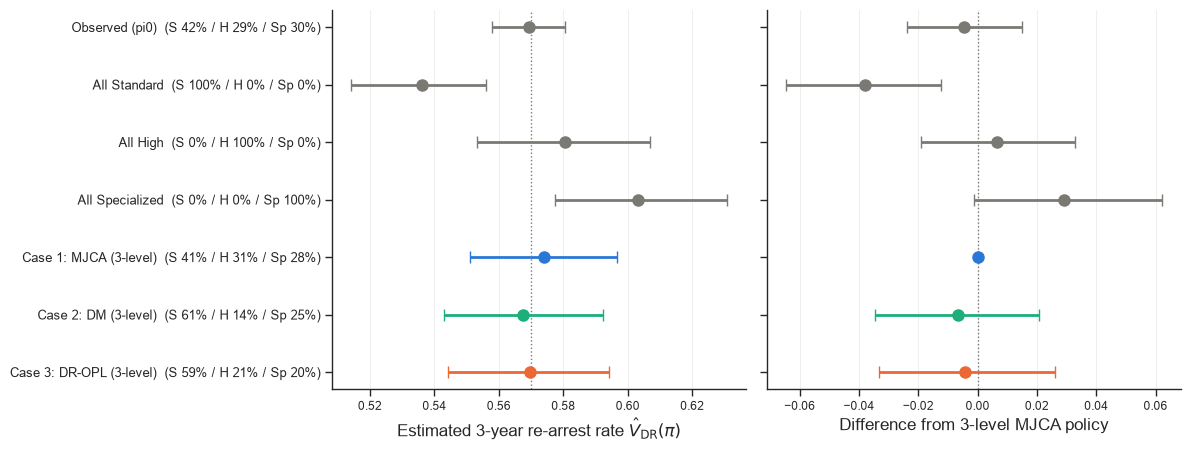

In [35]:
# @title 10b-4. 図 A3: 3 群の方策価値
order3 = list(policies3.keys())
colors3 = [C_GRAY, C_GRAY, C_GRAY, C_GRAY, C_BLUE, C_AQUA, C_ORANGE]
r3 = res3.loc[order3]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
y = np.arange(len(order3))[::-1]
for yi, (k, row), c in zip(y, r3.iterrows(), colors3):
    axes[0].errorbar(row.V_DR, yi, xerr=[[row.V_DR - row.DR_lo], [row.DR_hi - row.V_DR]], fmt='o', color=c, ms=8, capsize=4, lw=2)
    axes[1].errorbar(row.diff_vs_MJCA, yi, xerr=[[row.diff_vs_MJCA - row.diff_lo], [row.diff_hi - row.diff_vs_MJCA]], fmt='o', color=c, ms=8, capsize=4, lw=2)
axes[0].axvline(r_te3.mean(), color=C_GRAY, ls=':', lw=1)
axes[1].axvline(0, color=C_GRAY, ls=':', lw=1)
labels3 = [f"{k}  (S {r3.loc[k, 'share_Standard']:.0%} / H {r3.loc[k, 'share_High']:.0%} / Sp {r3.loc[k, 'share_Specialized']:.0%})" for k in order3]
axes[0].set_yticks(y); axes[0].set_yticklabels(labels3, fontsize=9)
axes[0].set_xlabel(r'Estimated 3-year re-arrest rate $\hat V_{\mathrm{DR}}(\pi)$', fontsize=12)
axes[1].set_xlabel('Difference from 3-level MJCA policy', fontsize=12)
for ax in axes:
    ax.grid(axis='x', alpha=0.3); sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG / 'figA3_multiclass_policy_values.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. 計画からの逸脱の記録

- R4（High vs Standard のみ）を頑健性チェックに追加した。EDA で、Violent/Sex の 96% が Specialized であり、Specialized は「High より強い監督」ではなく罪種に応じた別種の処遇である可能性が高いと分かったため（処遇の一意性、つまり SUTVA の懸念）。
- （2026-09-29、ユーザーとの協議により改訂）Georgia の初回リスクスコア（`risk_score`, `risk_score_missing`）を方策の入力から外した。交絡調整には残す。旧仕様は R7、スコア順の方策は付録のベンチマーク（§8-4）として報告する。結果を見た後の変更なので、ここに明記する。
- 仮釈放条件 `Condition_*` を主分析の共変量に含めた。codebook 上、仮釈放委員会が釈放時に設定するもので、監督レベルの決定（監督開始時）より前に確定しているため。
- 既存の方策学習コードの 2 点を修正して流用した（§4）。
- （2026-09-29、ユーザー指摘）学習に使う情報を全手法でそろえた。以前は DR-learner・DR-OPL の学習用 nuisance だけが全共変量（リスクスコア・Race を含む）を使っており、MJCA 型 $q(x)$ との比較が apples-to-apples でなかった。評価用 nuisance は全方策に共通なので全共変量のまま。
- （2026-09-29、ユーザーとの協議）付録 B として 3 群の多クラス OPL（§10b）を追加した。High vs Standard のみの仕様（R4）は overlap が悪い（$[0.05, 0.95]$ の外側 36%）ので、主仕様にはせず付録 A とした。
- （2026-09-29 ユーザー指摘により改訂）
  - DR-learner（Case 2b）を追加し、処遇容量カーブの「DR 順」を NN 方策の確率から $\hat b_{\rm DR}(x)$ に変更した。NN 方策の確率は容量制約なしで学習しており、順位スコアとしての根拠がないため。
  - Case 3（NN）の定義を、全図表で「10 seed の平均方策」に統一した。以前は図 3 が seed 0、図 4 が 10 seed 平均で、定義が食い違っていた。NN の確率に基づく「容量一致」版は削除した。
  - 傾向スコアの較正チェック（§3-4）と、ロジスティック回帰の傾向スコアを使う頑健性チェック（R6）を追加した。